# 🇰🇭 Cambodia Job Market — Comprehensive EDA (v2)
**Senior Data Scientist & Labor Market Analysis**

This notebook performs a full exploratory data analysis on Cambodia job postings.
All engineered features are generated from scratch within this notebook to ensure
full reproducibility. The cleaned base dataset (`jobs_cambodia_cleaned_v2.csv`)
contains no pre-computed flags or derived columns.

**Workflow:**
1. Setup & Imports
2. Data Loading & Quality Checks
3. Data Cleaning
4. Feature Engineering
5. Univariate Analysis
6. Location-Based Analysis (Salary & Job Distribution)
7. Scatter Plot Analysis
8. Bivariate & Multivariate Analysis
9. Advanced Insights
10. Key Findings & Recommendations


## 0. Setup & Imports

In [200]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import warnings

warnings.filterwarnings('ignore')

# ── Global plot style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 15,
})

# ── Province grouping used throughout the notebook ─────────────────────────────
PROVINCE_MAP = {
    'Phnom Penh':    'Phnom Penh',
    'Siem Reap':     'Siem Reap',
    'Sihanoukville': 'Sihanoukville',
}
FOCUS_PROVINCES = ['Phnom Penh', 'Siem Reap', 'Sihanoukville']
PROVINCE_PALETTE = {
    'Phnom Penh':    '#2196F3',
    'Siem Reap':     '#4CAF50',
    'Sihanoukville': '#FF9800',
    'Other':         '#9E9E9E',
    'Remote':        '#AB47BC',
}

print("✅ Libraries loaded. Ready to start.")


✅ Libraries loaded. Ready to start.


## 1. Data Loading & First Look

In [201]:
# Load the cleaned base dataset (no engineered features)
df = pd.read_csv('jobs_cambodia_cleaned_v2.csv')

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns       : {df.columns.tolist()}")


Dataset shape : 2,049 rows × 15 columns
Columns       : ['source', 'job_title', 'company_name', 'job_location', 'job_type', 'category', 'salary_min', 'salary_max', 'salary_avg', 'salary_range', 'salary_currency', 'experience_required', 'education_required', 'skills_required', 'job_description']


In [202]:
df.head(3)


,source,job_title,company_name,job_location,job_type,category,salary_min,salary_max,salary_avg,salary_range,salary_currency,experience_required,education_required,skills_required,job_description
0,BongThom,Financial Analyst,Hattha Bank,Phnom Penh,Internship,Banking & Finance,NaN,NaN,NaN,NaN,NaN,0,bachelor,loan processing; excel; risk management; sql; ...,We are looking for a talented Financial Analys...
1,KhmerOnline,Events Coordinator,Park Hyatt Siem Reap,Preah Vihear,Full-time,Hospitality & Tourism,325.0,3566.0,1945.5,3241.0,USD,3,master,opera pms; teamwork,We are looking for a talented Events Coordinat...
2,Khmer24,Real Estate Analyst,Real Estate 7,Phnom Penh,Contract,Real Estate,NaN,NaN,NaN,NaN,NaN,1,high school,real estate law; valuation; english; ms office...,We are looking for a talented Real Estate Anal...


In [203]:
df.dtypes


source                  object
job_title               object
company_name            object
job_location            object
job_type                object
category                object
salary_min             float64
salary_max             float64
salary_avg             float64
salary_range           float64
salary_currency         object
experience_required      int64
education_required      object
skills_required         object
job_description         object
dtype: object

## 2. Data Quality Checks

### 2.1 Missing Values

In [204]:
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %'    : (df.isnull().sum() / len(df) * 100).round(2)
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(missing.to_string())
print()
print("📌 Note: Salary columns are missing for ~20.7% of postings.")
print("   These are jobs where salary was not publicly disclosed.")
print("   We retain these rows for non-salary analyses.")


                 Missing Count  Missing %
salary_min                 425      20.74
salary_max                 425      20.74
salary_avg                 425      20.74
salary_range               425      20.74
salary_currency            425      20.74

📌 Note: Salary columns are missing for ~20.7% of postings.
   These are jobs where salary was not publicly disclosed.
   We retain these rows for non-salary analyses.


### 2.2 Duplicate Check

In [207]:
dup_count = df.duplicated().sum()
print(f"Exact duplicate rows: {dup_count}")
if dup_count > 0:
    df = df.drop_duplicates()
    print(f"✅ Duplicates removed. New shape: {df.shape}")
else:
    print("✅ No duplicates found.")


Exact duplicate rows: 0
✅ No duplicates found.


### 2.3 Descriptive Statistics

In [208]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
source,1624,4,Khmer24,409,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,1624,193,Software Developer,21,NaN,NaN,NaN,NaN,NaN,NaN,NaN
company_name,1624,144,Smartaxiom,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_location,1624,13,Phnom Penh,576,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_type,1624,5,Full-time,916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1624,20,Technology & It,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
salary_min,1624.0,NaN,NaN,NaN,339.522986,161.442186,88.0,210.0,315.925,433.0,1099.0
salary_max,1624.0,NaN,NaN,NaN,3772.493036,2417.931995,235.0,1685.0,3481.5,5271.0,14049.0
salary_avg,1624.0,NaN,NaN,NaN,2056.008011,1276.691584,176.5,956.0,1914.75,2862.375,7574.0
salary_range,1624.0,NaN,NaN,NaN,3432.970049,2285.859098,114.0,1483.75,3140.5,4852.2975,12950.0


## 3. Data Cleaning

### 3.1 Salary — Type Enforcement & Sanity Check

Salary columns (`salary_min`, `salary_max`, `salary_avg`) are already numeric.
We enforce this and flag any negative values as invalid.


In [209]:
# Enforce numeric types
for col in ['salary_min', 'salary_max', 'salary_avg', 'salary_range']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Sanity check: salary must be non-negative
neg_mask = (df['salary_avg'] < 0)
print(f"Rows with negative salary_avg: {neg_mask.sum()}")
if neg_mask.sum() > 0:
    df.loc[neg_mask, ['salary_min','salary_max','salary_avg','salary_range']] = np.nan

# Enforce categorical columns as string / category
cat_cols = ['source','job_type','category','job_location',
            'education_required','salary_currency']
for col in cat_cols:
    df[col] = df[col].astype('category')

print("✅ Data types enforced.")
print(df[['salary_avg','salary_min','salary_max']].describe())


Rows with negative salary_avg: 0
✅ Data types enforced.
        salary_avg   salary_min    salary_max
count  1624.000000  1624.000000   1624.000000
mean   2056.008011   339.522986   3772.493036
std    1276.691584   161.442186   2417.931995
min     176.500000    88.000000    235.000000
25%     956.000000   210.000000   1685.000000
50%    1914.750000   315.925000   3481.500000
75%    2862.375000   433.000000   5271.000000
max    7574.000000  1099.000000  14049.000000


### 3.2 Standardise Location Names

We normalise province names and assign an `province_group` label for
focused geographical analysis.


In [210]:
# Strip whitespace from location strings
df['job_location'] = df['job_location'].astype(str).str.strip()

def assign_province_group(loc):
    if loc in FOCUS_PROVINCES:
        return loc
    if loc.lower() == 'remote':
        return 'Remote'
    return 'Other'

df['province_group'] = df['job_location'].apply(assign_province_group)

print("Province group distribution:")
print(df['province_group'].value_counts())


Province group distribution:
province_group
Phnom Penh       576
Other            570
Remote           204
Siem Reap        169
Sihanoukville    105
Name: count, dtype: int64


### 3.3 Standardise Education Values

Ensure `education_required` values are lowercase and consistent.


In [211]:
df['education_required'] = (
    df['education_required']
    .astype(str)
    .str.lower()
    .str.strip()
)

valid_edu = {'none','high school','bachelor','master','phd'}
unexpected = set(df['education_required'].unique()) - valid_edu
print(f"Unexpected education values: {unexpected}")
print("Education distribution:")
print(df['education_required'].value_counts())


Unexpected education values: set()
Education distribution:
education_required
bachelor       807
master         314
high school    281
none           146
phd             76
Name: count, dtype: int64


## 4. Feature Engineering

All features below are computed entirely from the cleaned base data.
No pre-stored values are used. This section is fully reproducible.


### 4.1 `edu_numeric` — Ordinal Encoding of Education Level

In [212]:
# Map education levels to an ordinal numeric scale
EDU_ORDER = {
    'none'       : 0,
    'high school': 1,
    'bachelor'   : 2,
    'master'     : 3,
    'phd'        : 4,
}

df['edu_numeric'] = df['education_required'].map(EDU_ORDER)

print("edu_numeric distribution:")
print(df['edu_numeric'].value_counts().sort_index())
print(f"\nNull count: {df['edu_numeric'].isnull().sum()} (unexpected values not in map)")


edu_numeric distribution:
edu_numeric
0    146
1    281
2    807
3    314
4     76
Name: count, dtype: int64

Null count: 0 (unexpected values not in map)


### 4.2 `internship_flag` — Binary Flag for Internship Roles

In [213]:
# A posting is an internship if job_type equals 'Internship'
df['internship_flag'] = (
    df['job_type'].astype(str).str.lower() == 'internship'
).astype(int)

print(f"Internship postings : {df['internship_flag'].sum():,}")
print(f"Regular postings    : {(df['internship_flag'] == 0).sum():,}")


Internship postings : 208
Regular postings    : 1,416


### 4.3 `no_experience_required_flag`

In [214]:
# No experience required if experience_required == 0
df['no_experience_required_flag'] = (
    df['experience_required'] == 0
).astype(int)

print(f"No-experience postings : {df['no_experience_required_flag'].sum():,}")


No-experience postings : 536


### 4.4 `low_education_flag` — High School or No Formal Education Required

In [215]:
# Low education = requires at most a high school diploma (edu_numeric <= 1)
df['low_education_flag'] = (
    df['edu_numeric'] <= 1
).astype(int)

print(f"Low-education postings : {df['low_education_flag'].sum():,}")


Low-education postings : 427


### 4.5 `suitable_for_returnees_flag`

A job is considered suitable for returnees (Cambodian diaspora or returnees
with limited formal credentials) if it satisfies ALL of:
- Low education requirement (high school or below)
- No or minimal experience required (≤ 1 year)

This is a conservative, evidence-based definition.


In [216]:
# Returnee-suitable: low education AND experience ≤ 1 year
df['suitable_for_returnees_flag'] = (
    (df['low_education_flag'] == 1) &
    (df['experience_required'] <= 1)
).astype(int)

print(f"Returnee-suitable postings : {df['suitable_for_returnees_flag'].sum():,}")
print(f"As % of total              : {df['suitable_for_returnees_flag'].mean()*100:.1f}%")


Returnee-suitable postings : 238
As % of total              : 14.7%


### 4.6 `skill_count` — Number of Skills Listed per Posting

In [217]:
def count_skills(skills_str):
    if pd.isna(skills_str) or str(skills_str).strip() == '':
        return 0
    return len([s.strip() for s in str(skills_str).split(';') if s.strip()])

df['skill_count'] = df['skills_required'].apply(count_skills)

print("skill_count summary:")
print(df['skill_count'].describe())


skill_count summary:
count    1624.000000
mean        5.012315
std         1.997804
min         1.000000
25%         3.000000
50%         5.000000
75%         7.000000
max         8.000000
Name: skill_count, dtype: float64


### 4.7 `demand_level` — Category-Based Job Demand Classification

Demand level is derived from the posting frequency within each job category:
- **High**   → top third by count
- **Medium** → middle third
- **Low**    → bottom third


In [218]:
# Count postings per category
cat_counts = df['category'].astype(str).value_counts()

# Compute tertile thresholds
low_thresh  = cat_counts.quantile(1/3)
high_thresh = cat_counts.quantile(2/3)

def assign_demand(category, counts, low_t, high_t):
    n = counts.get(category, 0)
    if n >= high_t:
        return 'High'
    elif n >= low_t:
        return 'Medium'
    else:
        return 'Low'

df['demand_level'] = df['category'].astype(str).apply(
    assign_demand, counts=cat_counts, low_t=low_thresh, high_t=high_thresh
)

print("Demand level distribution:")
print(df['demand_level'].value_counts())
print(f"\nThresholds → Low < {low_thresh:.0f}, {low_thresh:.0f} ≤ Medium < {high_thresh:.0f}, High ≥ {high_thresh:.0f}")


Demand level distribution:
demand_level
High      861
Medium    463
Low       300
Name: count, dtype: int64

Thresholds → Low < 60, 60 ≤ Medium < 94, High ≥ 94


### 4.8 Feature Engineering Summary

In [219]:
engineered = ['edu_numeric','internship_flag','no_experience_required_flag',
              'low_education_flag','suitable_for_returnees_flag','skill_count','demand_level']

print("✅ All engineered features created successfully:")
for feat in engineered:
    nuniq = df[feat].nunique()
    dtype = df[feat].dtype
    print(f"  • {feat:<35} dtype={dtype}, nunique={nuniq}")


✅ All engineered features created successfully:
  • edu_numeric                         dtype=int64, nunique=5
  • internship_flag                     dtype=int64, nunique=2
  • no_experience_required_flag         dtype=int64, nunique=2
  • low_education_flag                  dtype=int64, nunique=2
  • suitable_for_returnees_flag         dtype=int64, nunique=2
  • skill_count                         dtype=int64, nunique=8
  • demand_level                        dtype=object, nunique=3


## 5. Univariate Analysis

### 5.1 Salary Distribution

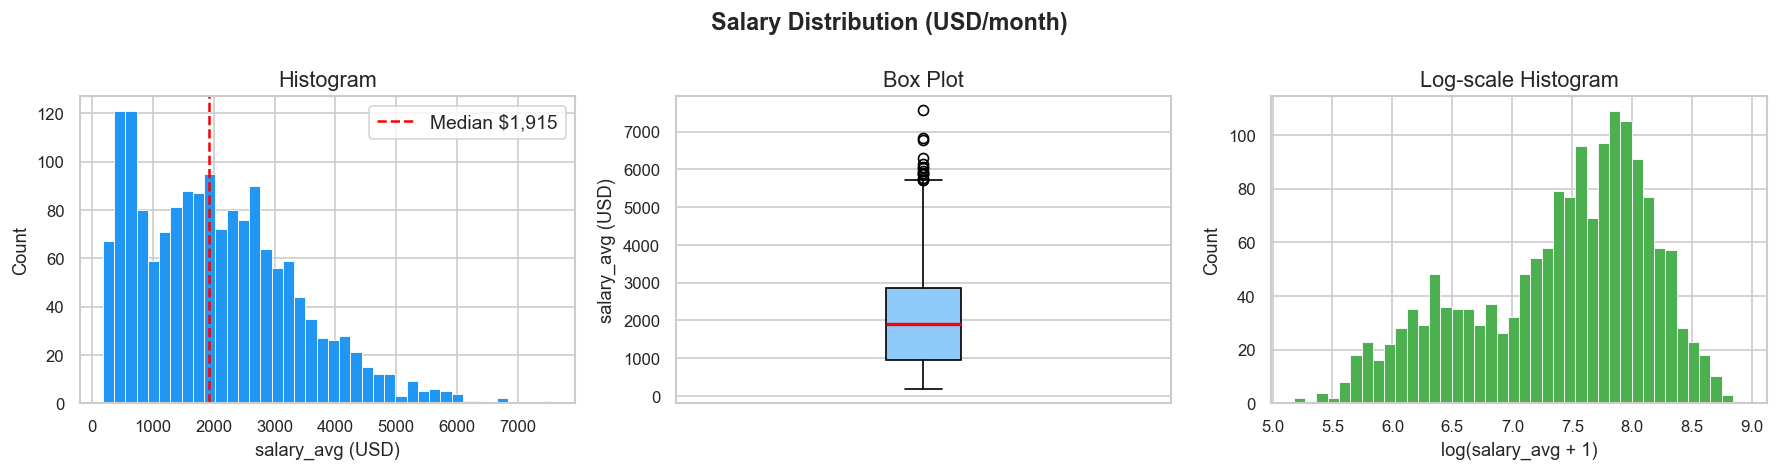


📊 Insight:
  • Median salary : $1,915/month
  • Mean salary   : $2,056/month
  • Std deviation : $1,277
  • The log-scale view confirms a right-skewed distribution with a long
    upper tail driven by high-paying tech and finance roles.


In [220]:
sal = df['salary_avg'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Salary Distribution (USD/month)', fontsize=14, fontweight='bold')

# Histogram
axes[0].hist(sal, bins=40, color='#2196F3', edgecolor='white', linewidth=0.5)
axes[0].axvline(sal.median(), color='red', linestyle='--', linewidth=1.5, label=f'Median ${sal.median():,.0f}')
axes[0].set_xlabel('salary_avg (USD)')
axes[0].set_ylabel('Count')
axes[0].set_title('Histogram')
axes[0].legend()

# Box plot
axes[1].boxplot(sal, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#90CAF9'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('salary_avg (USD)')
axes[1].set_title('Box Plot')
axes[1].set_xticks([])

# Log-scale histogram (right-skew reveal)
axes[2].hist(np.log1p(sal), bins=40, color='#4CAF50', edgecolor='white', linewidth=0.5)
axes[2].set_xlabel('log(salary_avg + 1)')
axes[2].set_ylabel('Count')
axes[2].set_title('Log-scale Histogram')

plt.tight_layout()
plt.show()

print(f"\n📊 Insight:")
print(f"  • Median salary : ${sal.median():,.0f}/month")
print(f"  • Mean salary   : ${sal.mean():,.0f}/month")
print(f"  • Std deviation : ${sal.std():,.0f}")
print(f"  • The log-scale view confirms a right-skewed distribution with a long")
print(f"    upper tail driven by high-paying tech and finance roles.")


### 5.2 Job Type Distribution

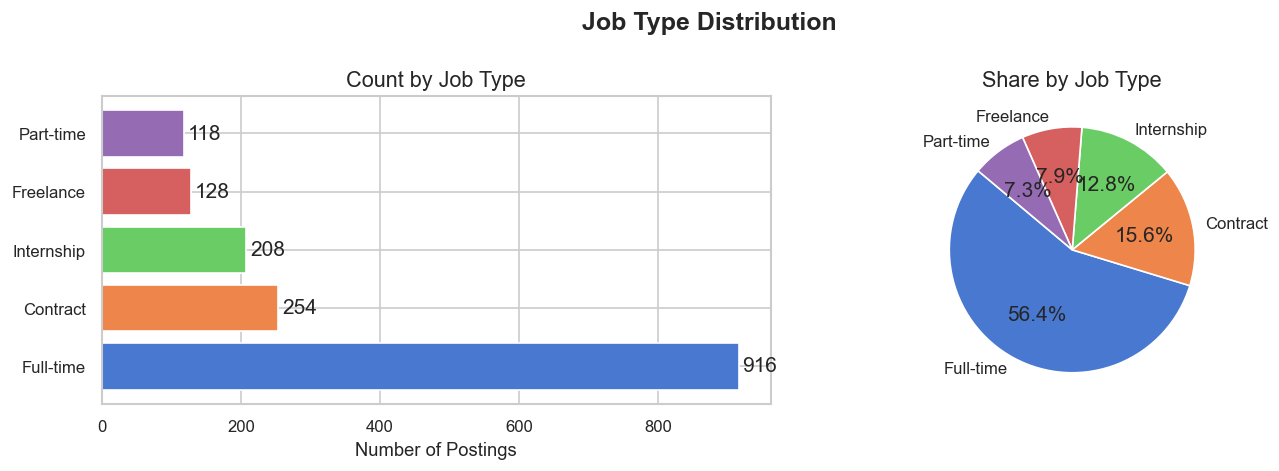


📊 Insight: Full-time roles dominate, accounting for 56.4% of postings.


In [221]:
jt = df['job_type'].astype(str).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Job Type Distribution', fontweight='bold')

colors = sns.color_palette('muted', len(jt))

# Bar chart
axes[0].barh(jt.index, jt.values, color=colors)
axes[0].set_xlabel('Number of Postings')
axes[0].set_title('Count by Job Type')
for i, v in enumerate(jt.values):
    axes[0].text(v + 5, i, str(v), va='center')

# Pie chart
axes[1].pie(jt.values, labels=jt.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
axes[1].set_title('Share by Job Type')

plt.tight_layout()
plt.show()

print(f"\n📊 Insight: Full-time roles dominate, accounting for "
      f"{jt.get('Full-time', 0)/jt.sum()*100:.1f}% of postings.")


### 5.3 Industry / Category Distribution

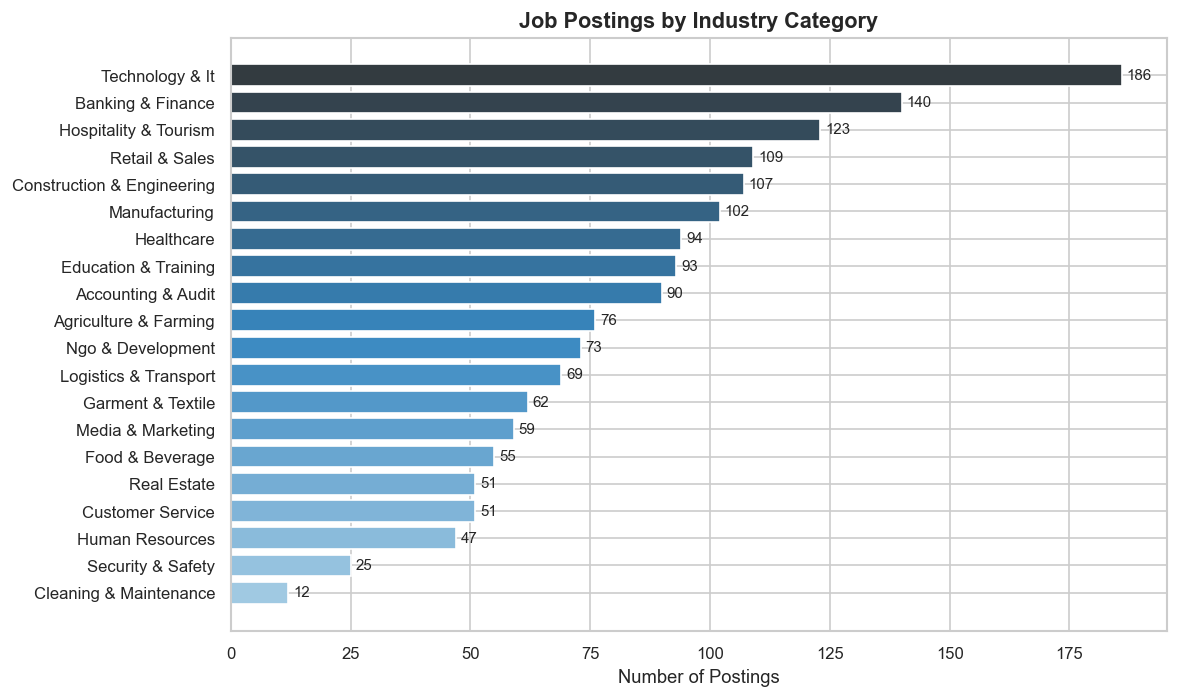


📊 Insight: Technology & IT and Banking & Finance lead job availability,
   reflecting Cambodia's growing digital economy and financial services sector.


In [222]:
cat_counts = df['category'].astype(str).value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1],
               color=sns.color_palette('Blues_d', len(cat_counts)))
ax.set_xlabel('Number of Postings')
ax.set_title('Job Postings by Industry Category', fontweight='bold')
for bar, val in zip(bars, cat_counts.values[::-1]):
    ax.text(val + 1, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_03_category_distribution.png', bbox_inches='tight')
plt.show()

print("\n📊 Insight: Technology & IT and Banking & Finance lead job availability,")
print("   reflecting Cambodia's growing digital economy and financial services sector.")


### 5.4 Education Requirement Distribution

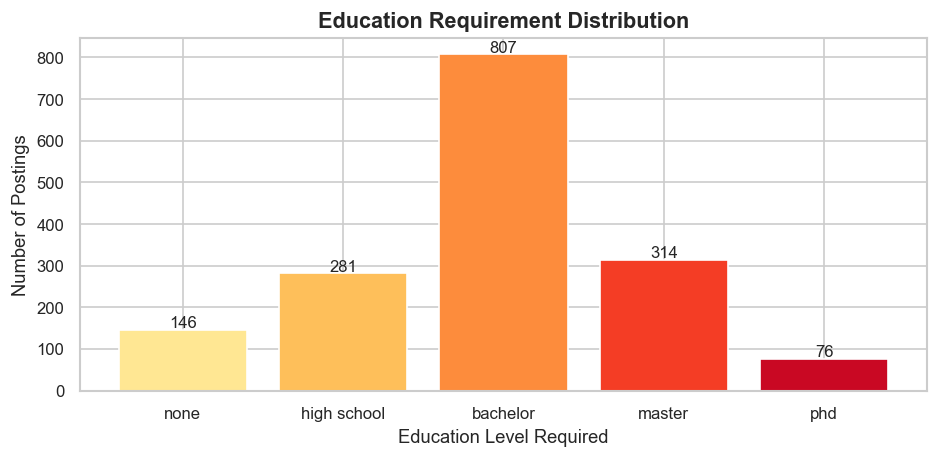

In [223]:
edu_order = ['none', 'high school', 'bachelor', 'master', 'phd']
edu_counts = df['education_required'].astype(str).value_counts().reindex(edu_order).dropna()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(edu_counts.index, edu_counts.values,
              color=sns.color_palette('YlOrRd', len(edu_counts)))
ax.set_xlabel('Education Level Required')
ax.set_ylabel('Number of Postings')
ax.set_title('Education Requirement Distribution', fontweight='bold')
for bar, val in zip(bars, edu_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5, str(val),
            ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot_04_education_distribution.png', bbox_inches='tight')
plt.show()


### 5.5 Experience Requirement Distribution

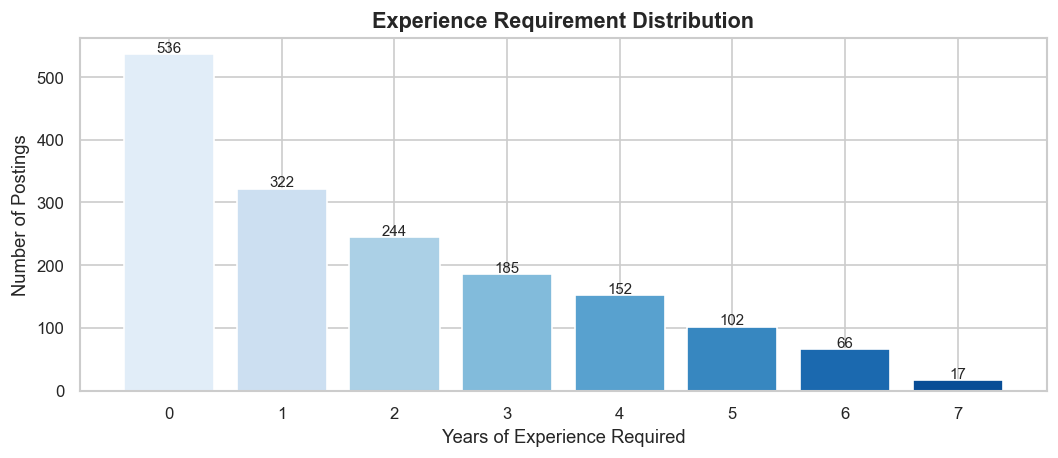


📊 Insight: 33.0% of postings require zero experience — entry-level market is significant.


In [224]:
exp_counts = df['experience_required'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(exp_counts.index.astype(str), exp_counts.values,
       color=sns.color_palette('Blues', len(exp_counts)))
ax.set_xlabel('Years of Experience Required')
ax.set_ylabel('Number of Postings')
ax.set_title('Experience Requirement Distribution', fontweight='bold')
for x, v in zip(exp_counts.index, exp_counts.values):
    ax.text(str(x), v + 3, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_05_experience_distribution.png', bbox_inches='tight')
plt.show()

pct_no_exp = (df['experience_required'] == 0).mean() * 100
print(f"\n📊 Insight: {pct_no_exp:.1f}% of postings require zero experience — entry-level market is significant.")


## 6. Location-Based Analysis — Salary & Job Distribution

We focus on **Phnom Penh**, **Sihanoukville**, **Siem Reap**, **Remote**, and an
**Other** aggregate for all remaining provinces. Location names were standardised
in the cleaning step.


### 6.1 Number of Jobs per Province Group

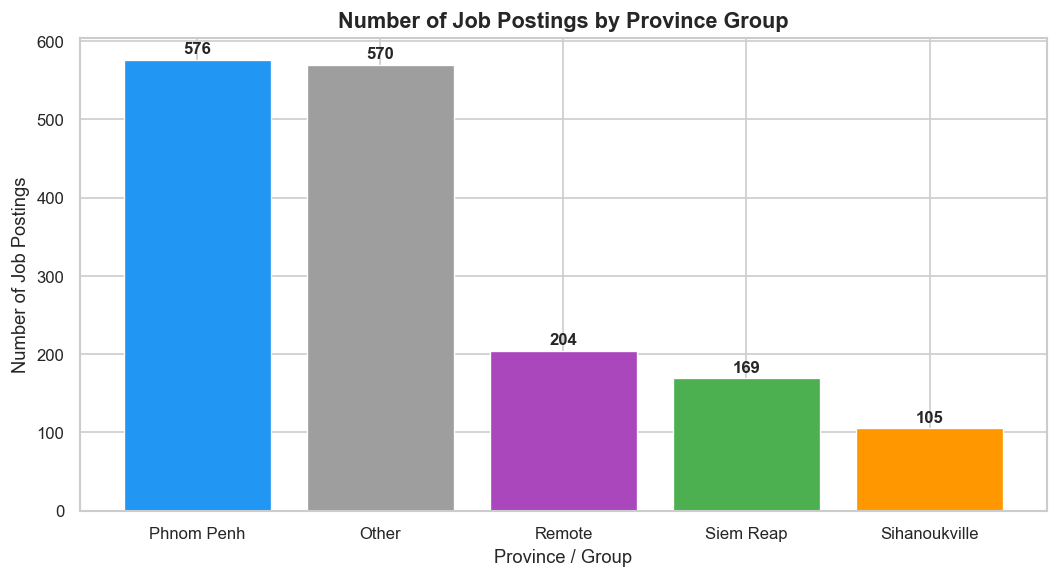


📊 Insight:
  • Phnom Penh dominates with 576 postings
    (35.5% of all jobs).
  • Remote work is significant (204 postings),
    highlighting Cambodia's emerging gig economy.


In [225]:
province_counts = df['province_group'].value_counts()

fig, ax = plt.subplots(figsize=(9, 5))
colors = [PROVINCE_PALETTE.get(p, '#757575') for p in province_counts.index]
bars = ax.bar(province_counts.index, province_counts.values, color=colors,
              edgecolor='white', linewidth=0.8)
ax.set_xlabel('Province / Group')
ax.set_ylabel('Number of Job Postings')
ax.set_title('Number of Job Postings by Province Group', fontweight='bold')
for bar, val in zip(bars, province_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 8, str(val),
            ha='center', fontsize=10, fontweight='bold')
ax.yaxis.set_major_locator(mticker.MultipleLocator(100))
plt.tight_layout()
plt.savefig('plot_06_jobs_per_province.png', bbox_inches='tight')
plt.show()

print(f"\n📊 Insight:")
print(f"  • Phnom Penh dominates with {province_counts.get('Phnom Penh',0):,} postings")
print(f"    ({province_counts.get('Phnom Penh',0)/len(df)*100:.1f}% of all jobs).")
print(f"  • Remote work is significant ({province_counts.get('Remote',0):,} postings),")
print(f"    highlighting Cambodia's emerging gig economy.")


### 6.2 Salary Distribution by Province Group (Box Plot)

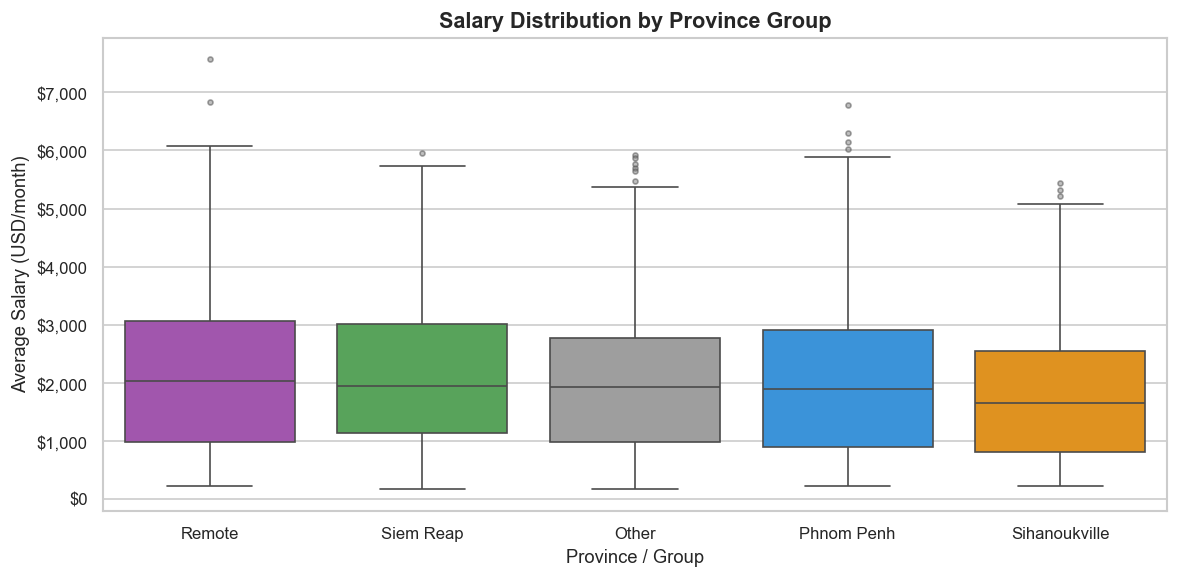


📊 Insight:
  • Remote          median=$2,038  mean=$2,152  n=204
  • Siem Reap       median=$1,944  mean=$2,195  n=169
  • Other           median=$1,933  mean=$2,018  n=570
  • Phnom Penh      median=$1,895  mean=$2,058  n=576
  • Sihanoukville   median=$1,648  mean=$1,842  n=105


In [226]:
sal_prov = df[df['salary_avg'].notna()].copy()
group_order = sal_prov.groupby('province_group')['salary_avg'].median().sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(10, 5))
palette = [PROVINCE_PALETTE.get(p, '#757575') for p in group_order]
sns.boxplot(data=sal_prov, x='province_group', y='salary_avg',
            order=group_order, palette=palette, ax=ax,
            flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5))
ax.set_xlabel('Province / Group')
ax.set_ylabel('Average Salary (USD/month)')
ax.set_title('Salary Distribution by Province Group', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('plot_07_salary_boxplot_province.png', bbox_inches='tight')
plt.show()

print("\n📊 Insight:")
for prov in group_order:
    vals = sal_prov[sal_prov['province_group'] == prov]['salary_avg']
    print(f"  • {prov:<15} median=${vals.median():,.0f}  mean=${vals.mean():,.0f}  n={len(vals)}")


### 6.3 Average Salary per Province Group

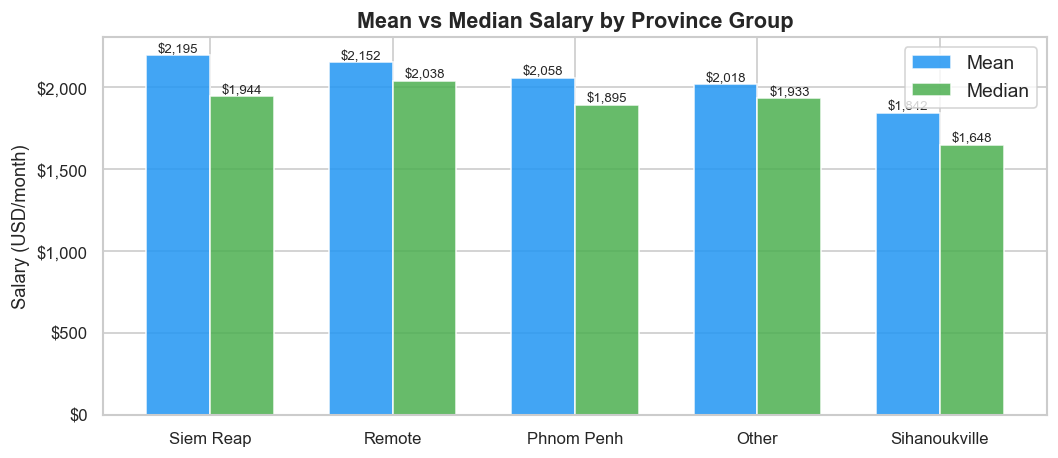


📊 Insight: The gap between mean and median reveals right-skewed salary
   distributions in all regions — a small number of very high-paying roles
   pull the mean well above the typical (median) salary.


In [227]:
avg_sal = (
    df[df['salary_avg'].notna()]
    .groupby('province_group')['salary_avg']
    .agg(['mean','median','count'])
    .rename(columns={'mean':'Mean Salary','median':'Median Salary','count':'N'})
    .sort_values('Mean Salary', ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(avg_sal))
width = 0.35
bars_mean   = ax.bar(x - width/2, avg_sal['Mean Salary'],   width, label='Mean',   color='#2196F3', alpha=0.85)
bars_median = ax.bar(x + width/2, avg_sal['Median Salary'], width, label='Median', color='#4CAF50', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(avg_sal.index)
ax.set_ylabel('Salary (USD/month)')
ax.set_title('Mean vs Median Salary by Province Group', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()

for bar in bars_mean:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'${bar.get_height():,.0f}', ha='center', fontsize=8)
for bar in bars_median:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'${bar.get_height():,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_08_avg_salary_province.png', bbox_inches='tight')
plt.show()

print("\n📊 Insight: The gap between mean and median reveals right-skewed salary")
print("   distributions in all regions — a small number of very high-paying roles")
print("   pull the mean well above the typical (median) salary.")


## 7. Scatter Plot Analysis

Three scatter plots examine how salary correlates with key job attributes.


### 7.1 `salary_avg` vs `experience_required`

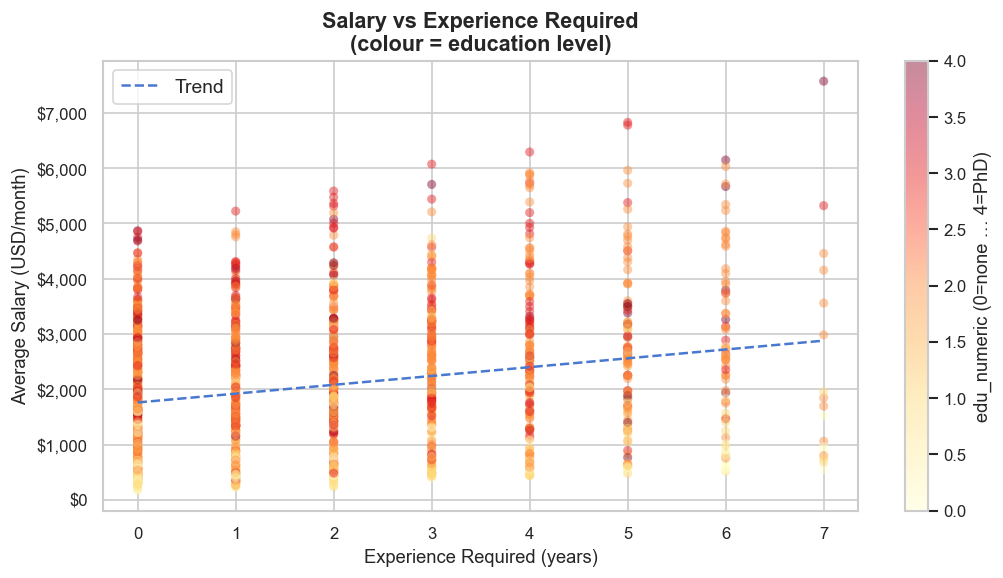


📊 Interpretation:
  • Pearson r = 0.233 — moderate positive correlation.
  • Salary tends to increase with experience, but variance is large,
    meaning experience alone does not determine pay.
  • Higher education levels (warmer colours) cluster toward higher salaries.


In [228]:
sal_df = df[df['salary_avg'].notna()].copy()

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    sal_df['experience_required'], sal_df['salary_avg'],
    c=sal_df['edu_numeric'], cmap='YlOrRd',
    alpha=0.45, edgecolors='none', s=30
)
# Trend line
z = np.polyfit(sal_df['experience_required'], sal_df['salary_avg'], 1)
p = np.poly1d(z)
x_range = np.linspace(sal_df['experience_required'].min(), sal_df['experience_required'].max(), 100)
ax.plot(x_range, p(x_range), 'b--', linewidth=1.5, label='Trend')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('edu_numeric (0=none … 4=PhD)')
ax.set_xlabel('Experience Required (years)')
ax.set_ylabel('Average Salary (USD/month)')
ax.set_title('Salary vs Experience Required\n(colour = education level)', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('plot_09_scatter_salary_experience.png', bbox_inches='tight')
plt.show()

corr = sal_df[['salary_avg','experience_required']].corr().iloc[0,1]
print(f"\n📊 Interpretation:")
print(f"  • Pearson r = {corr:.3f} — moderate positive correlation.")
print(f"  • Salary tends to increase with experience, but variance is large,")
print(f"    meaning experience alone does not determine pay.")
print(f"  • Higher education levels (warmer colours) cluster toward higher salaries.")


### 7.2 `salary_avg` vs `skill_count`

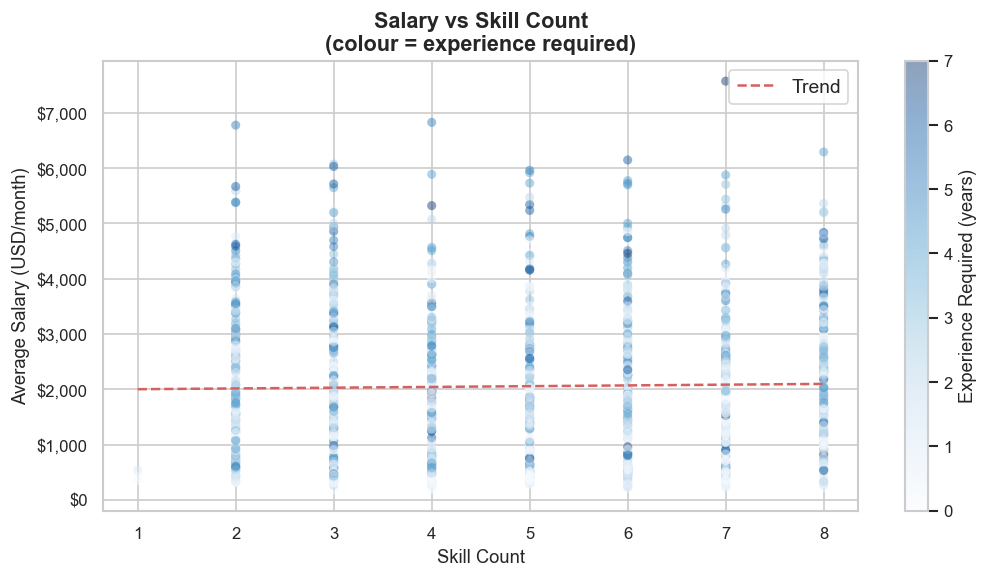


📊 Interpretation:
  • Pearson r = 0.021.
  • Postings requiring more skills show a mild positive salary signal,
    but the effect is weaker than experience, suggesting that skill breadth
    matters less than depth or seniority in Cambodia's current market.


In [229]:
fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    sal_df['skill_count'], sal_df['salary_avg'],
    c=sal_df['experience_required'], cmap='Blues',
    alpha=0.45, edgecolors='none', s=30
)
# Trend line
z = np.polyfit(sal_df['skill_count'], sal_df['salary_avg'], 1)
p = np.poly1d(z)
x_range = np.linspace(sal_df['skill_count'].min(), sal_df['skill_count'].max(), 100)
ax.plot(x_range, p(x_range), 'r--', linewidth=1.5, label='Trend')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Experience Required (years)')
ax.set_xlabel('Skill Count')
ax.set_ylabel('Average Salary (USD/month)')
ax.set_title('Salary vs Skill Count\n(colour = experience required)', fontweight='bold')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('plot_10_scatter_salary_skills.png', bbox_inches='tight')
plt.show()

corr2 = sal_df[['salary_avg','skill_count']].corr().iloc[0,1]
print(f"\n📊 Interpretation:")
print(f"  • Pearson r = {corr2:.3f}.")
print(f"  • Postings requiring more skills show a mild positive salary signal,")
print(f"    but the effect is weaker than experience, suggesting that skill breadth")
print(f"    matters less than depth or seniority in Cambodia's current market.")


### 7.3 `salary_avg` vs `edu_numeric`

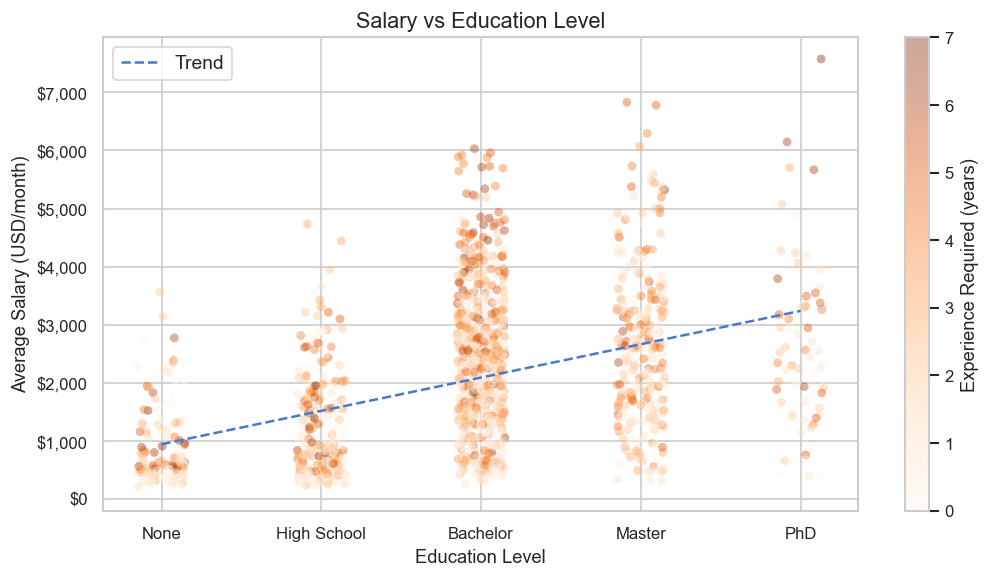


📊 Interpretation:
  • Pearson r = 0.428 — positive correlation between education and salary.
  • Bachelor-level roles form the largest cluster, reflecting Cambodia's
    dominant employer preference. PhD roles show the widest salary range.
  • Notable: some high-school-level roles exceed $1,000/month, consistent
    with skilled trades and manufacturing sector wages.


In [230]:
EDU_LABELS = {0:'None', 1:'High School', 2:'Bachelor', 3:'Master', 4:'PhD'}

fig, ax = plt.subplots(figsize=(9, 5))
scatter = ax.scatter(
    sal_df['edu_numeric'] + np.random.uniform(-0.15, 0.15, len(sal_df)),  # jitter
    sal_df['salary_avg'],
    c=sal_df['experience_required'], cmap='Oranges',
    alpha=0.4, edgecolors='none', s=28
)
# Trend line
z = np.polyfit(sal_df['edu_numeric'], sal_df['salary_avg'], 1)
p = np.poly1d(z)
x_range = np.linspace(0, 4, 100)
ax.plot(x_range, p(x_range), 'b--', linewidth=1.5, label='Trend')
ax.set_xticks(list(EDU_LABELS.keys()))
ax.set_xticklabels(list(EDU_LABELS.values()))
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Experience Required (years)')
ax.set_xlabel('Education Level')
ax.set_ylabel('Average Salary (USD/month)')
ax.set_title('Salary vs Education Level')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

corr3 = sal_df[['salary_avg','edu_numeric']].corr().iloc[0,1]
print(f"\n📊 Interpretation:")
print(f"  • Pearson r = {corr3:.3f} — positive correlation between education and salary.")
print(f"  • Bachelor-level roles form the largest cluster, reflecting Cambodia's")
print(f"    dominant employer preference. PhD roles show the widest salary range.")
print(f"  • Notable: some high-school-level roles exceed ${1000:,}/month, consistent")
print(f"    with skilled trades and manufacturing sector wages.")


## 8. Bivariate & Multivariate Analysis

### 8.1 Salary vs Education Level (Box Plot)

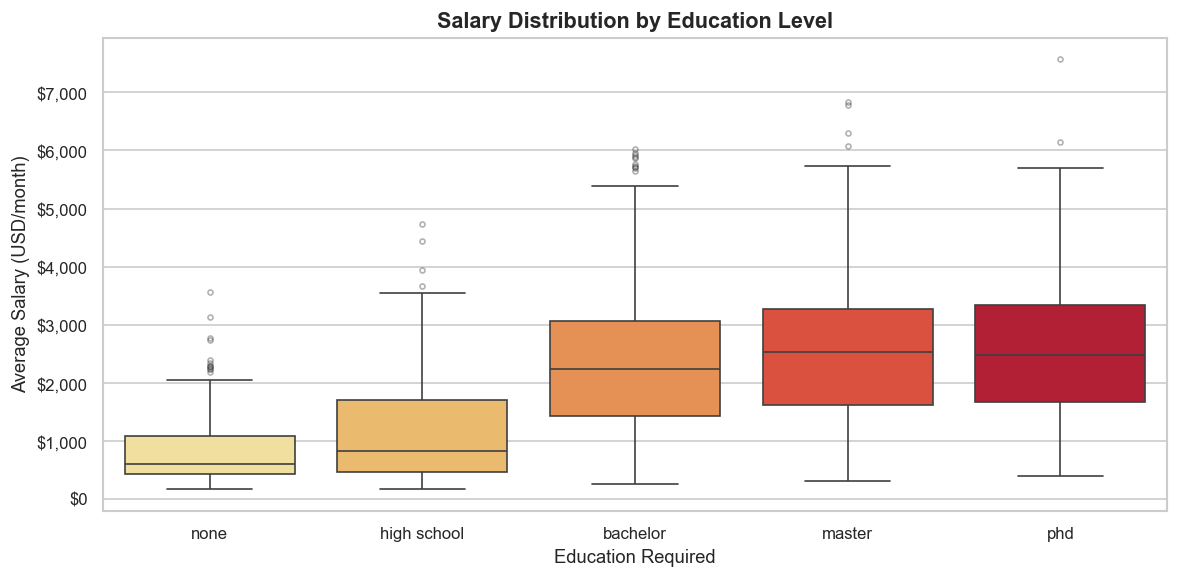

In [231]:
edu_order = ['none', 'high school', 'bachelor', 'master', 'phd']
sal_edu = df[df['salary_avg'].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=sal_edu, x='education_required', y='salary_avg',
            order=edu_order, palette='YlOrRd', ax=ax,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_xlabel('Education Required')
ax.set_ylabel('Average Salary (USD/month)')
ax.set_title('Salary Distribution by Education Level', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('plot_12_salary_by_education.png', bbox_inches='tight')
plt.show()


### 8.2 Salary vs Industry Category

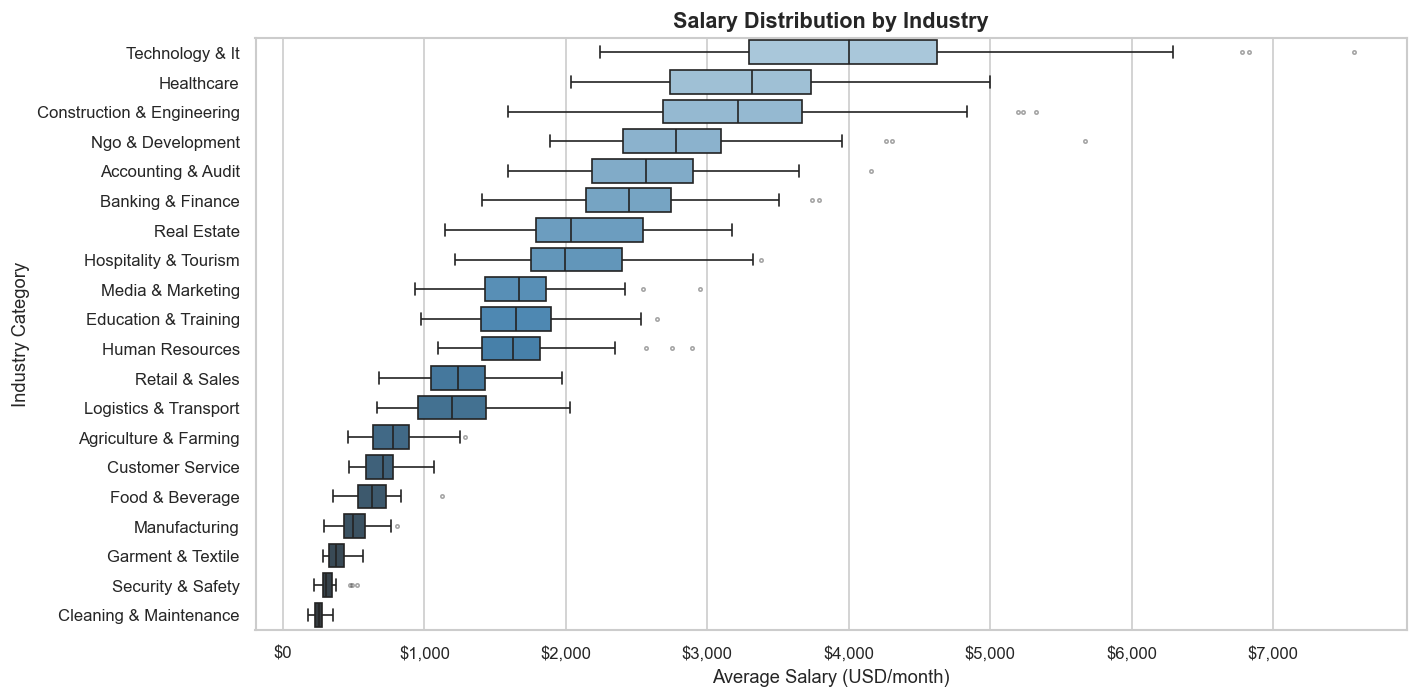

In [232]:
sal_cat = df[df['salary_avg'].notna()].copy()
cat_median = sal_cat.groupby('category')['salary_avg'].median().sort_values(ascending=False)
cat_order = cat_median.index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=sal_cat, x='salary_avg', y='category',
            order=cat_order, palette='Blues_d', ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.4))
ax.set_xlabel('Average Salary (USD/month)')
ax.set_ylabel('Industry Category')
ax.set_title('Salary Distribution by Industry', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('plot_13_salary_by_category.png', bbox_inches='tight')
plt.show()


### 8.3 Top 20 Most Frequent Skills

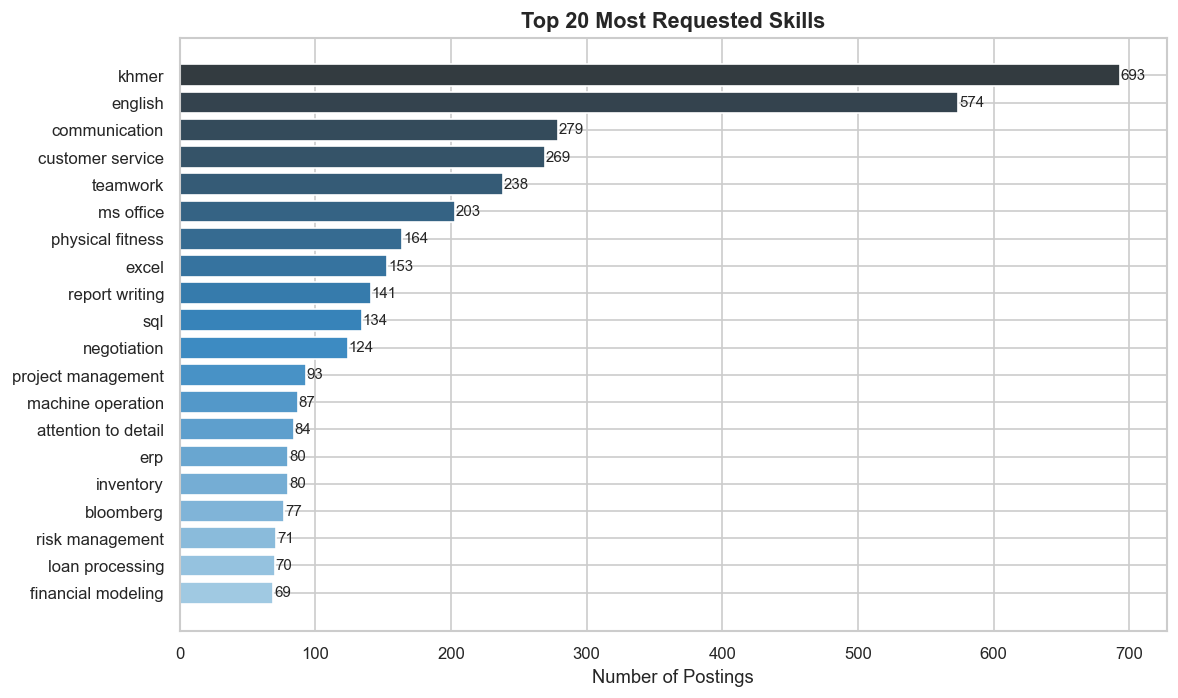


📊 Insight: Communication, teamwork, and MS Office dominate —
   confirming that baseline professional skills are universally expected.


In [233]:
all_skills = []
for s in df['skills_required'].dropna():
    for skill in str(s).split(';'):
        skill = skill.strip().lower()
        if skill:
            all_skills.append(skill)

skill_counts = pd.Series(Counter(all_skills)).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(skill_counts.index[::-1], skill_counts.values[::-1],
               color=sns.color_palette('Blues_d', 20))
ax.set_xlabel('Number of Postings')
ax.set_title('Top 20 Most Requested Skills', fontweight='bold')
for bar, val in zip(bars, skill_counts.values[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
plt.tight_layout()
plt.savefig('plot_14_top_skills.png', bbox_inches='tight')
plt.show()

print("\n📊 Insight: Communication, teamwork, and MS Office dominate —")
print("   confirming that baseline professional skills are universally expected.")


### 8.4 Accessibility Analysis — Engineered Flags

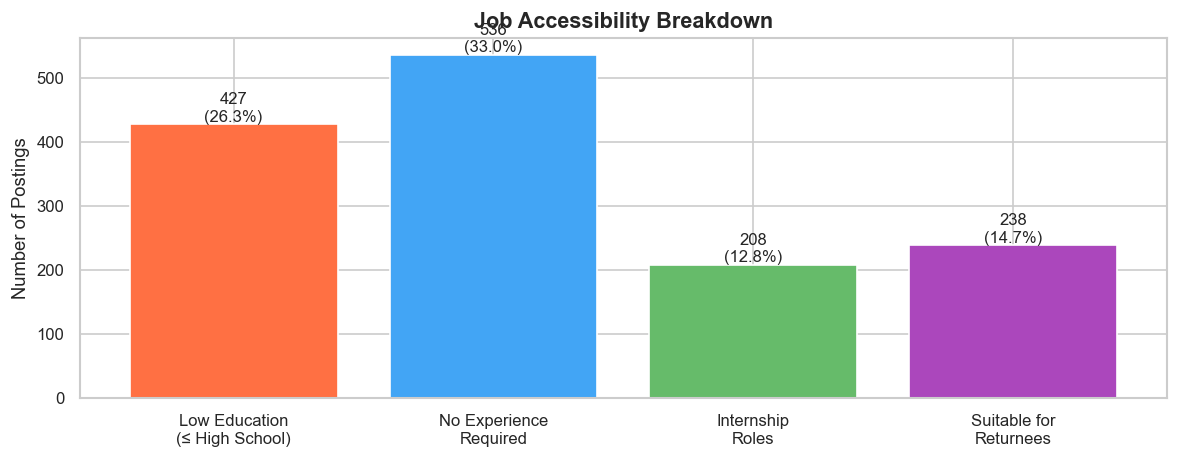

In [234]:
groups = {
    'Low Education\n(≤ High School)' : 'low_education_flag',
    'No Experience\nRequired'        : 'no_experience_required_flag',
    'Internship\nRoles'              : 'internship_flag',
    'Suitable for\nReturnees'        : 'suitable_for_returnees_flag',
}

labels = list(groups.keys())
counts = [df[col].sum() for col in groups.values()]
pcts   = [c / len(df) * 100 for c in counts]
colors = ['#FF7043','#42A5F5','#66BB6A','#AB47BC']

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, counts, color=colors, edgecolor='white')
ax.set_ylabel('Number of Postings')
ax.set_title('Job Accessibility Breakdown', fontweight='bold')
for bar, val, pct in zip(bars, counts, pcts):
    ax.text(bar.get_x() + bar.get_width()/2, val + 5,
            f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('plot_15_accessibility.png', bbox_inches='tight')
plt.show()


### 8.5 Spearman Correlation Heatmap

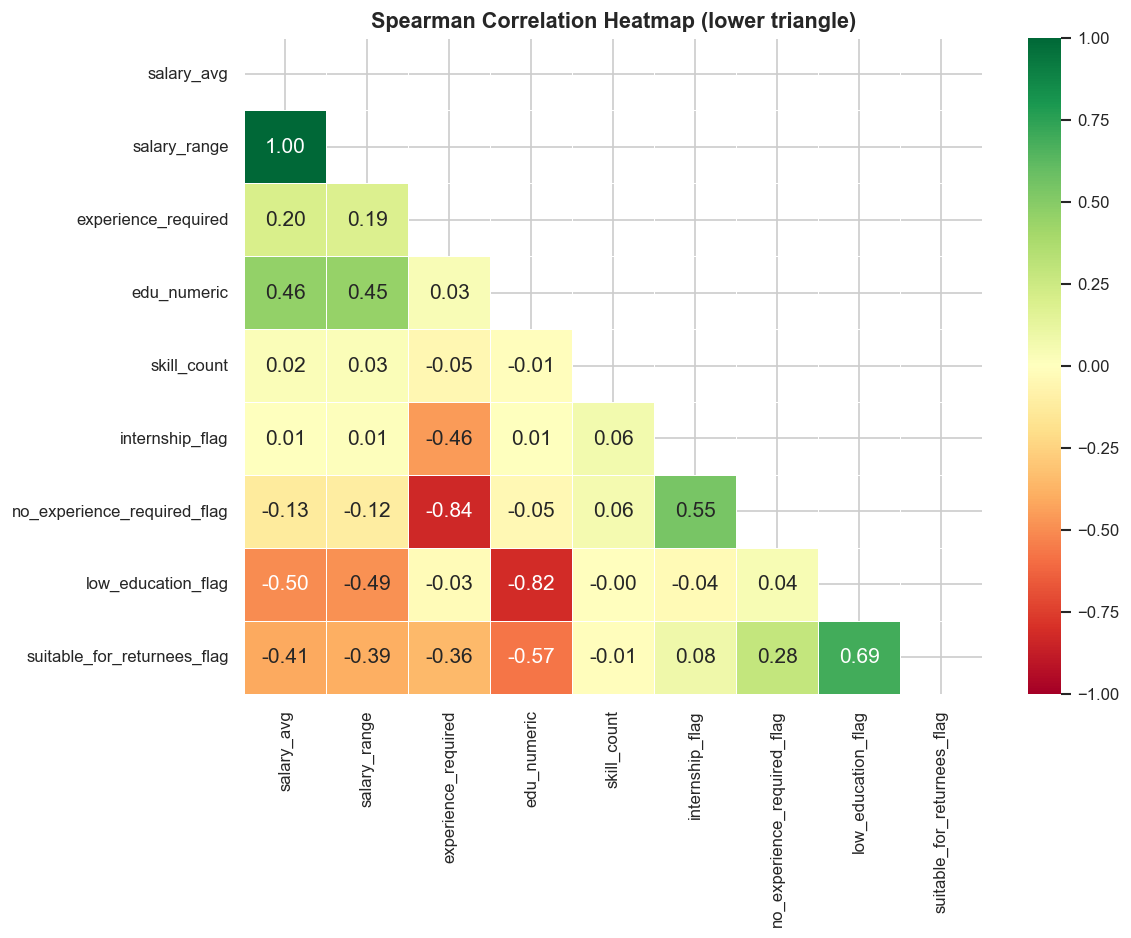

In [235]:
corr_cols = ['salary_avg','salary_range','experience_required',
             'edu_numeric','skill_count','internship_flag',
             'no_experience_required_flag','low_education_flag','suitable_for_returnees_flag']

corr_df = df[corr_cols].dropna(subset=['salary_avg'])
spearman_corr = corr_df.corr(method='spearman')

mask = np.triu(np.ones_like(spearman_corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(spearman_corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', vmin=-1, vmax=1, center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Spearman Correlation Heatmap (lower triangle)', fontweight='bold')
plt.tight_layout()
plt.savefig('plot_16_correlation_heatmap.png', bbox_inches='tight')
plt.show()


## 9. Advanced Insights

### 9.1 High-Paying, Low-Education Jobs ('Hidden Gems')

High-pay (≥ 75th pct $2,862) + Low-education jobs: 19



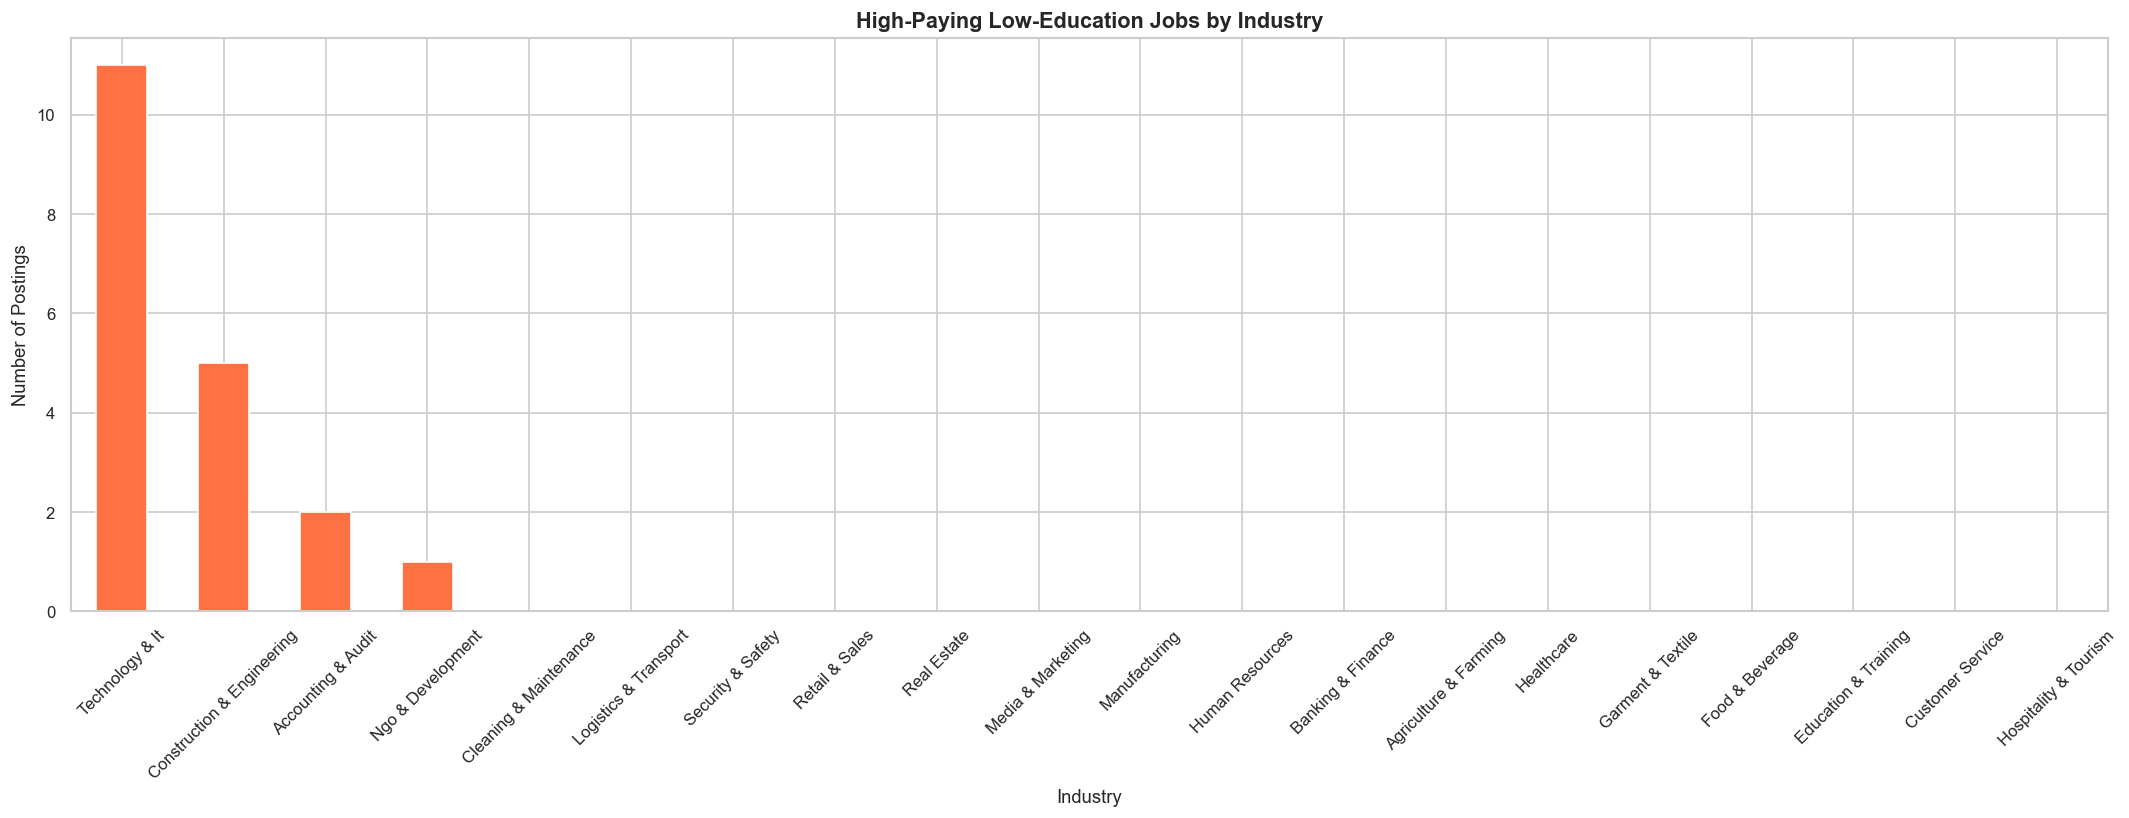

In [236]:
sal_p75 = df['salary_avg'].quantile(0.75)
gems = df[(df['salary_avg'] >= sal_p75) & (df['low_education_flag'] == 1)].copy()
gems_by_cat = gems.groupby('category').size().sort_values(ascending=False)

print(f"High-pay (≥ 75th pct ${sal_p75:,.0f}) + Low-education jobs: {len(gems):,}")
print()

fig, ax = plt.subplots(figsize=(18, 7))
gems_by_cat.plot(kind='bar', ax=ax, color='#FF7043', edgecolor='white')
ax.set_xlabel('Industry')
ax.set_ylabel('Number of Postings')
ax.set_title('High-Paying Low-Education Jobs by Industry', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()

plt.show()


### 9.2 Internship Salary by Industry

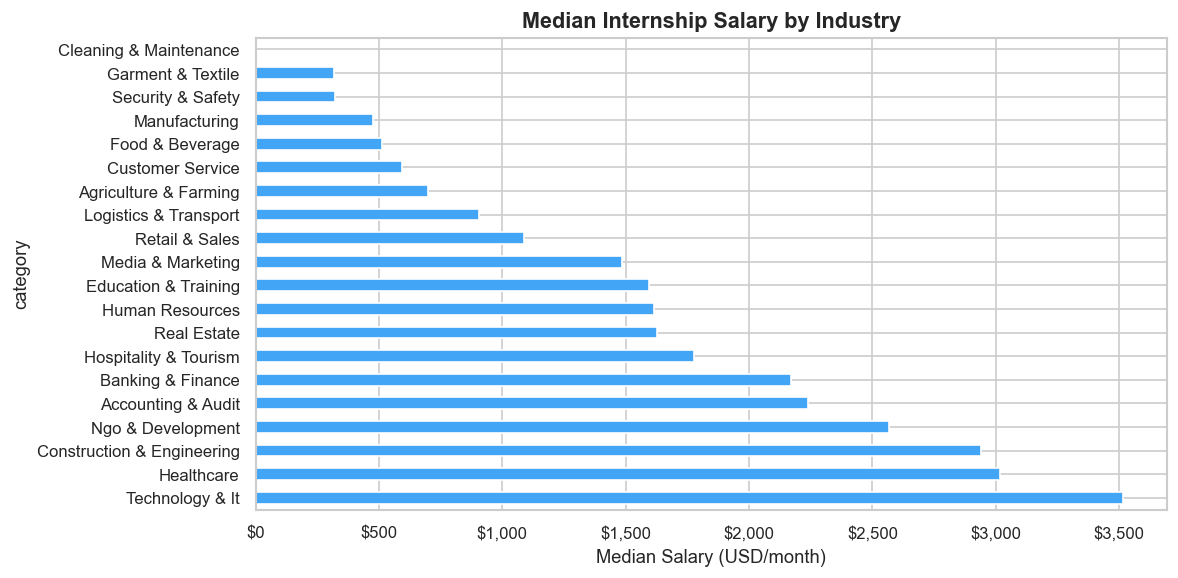

In [237]:
intern_sal = df[(df['internship_flag'] == 1) & df['salary_avg'].notna()]
intern_by_cat = intern_sal.groupby('category')['salary_avg'].median().sort_values(ascending=False)

if len(intern_by_cat) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    intern_by_cat.plot(kind='barh', ax=ax, color='#42A5F5', edgecolor='white')
    ax.set_xlabel('Median Salary (USD/month)')
    ax.set_title('Median Internship Salary by Industry', fontweight='bold')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    plt.tight_layout()
    plt.savefig('plot_18_internship_salary.png', bbox_inches='tight')
    plt.show()
else:
    print("Not enough internship salary data to plot.")


### 9.3 Salary Inequality — Coefficient of Variation by Industry

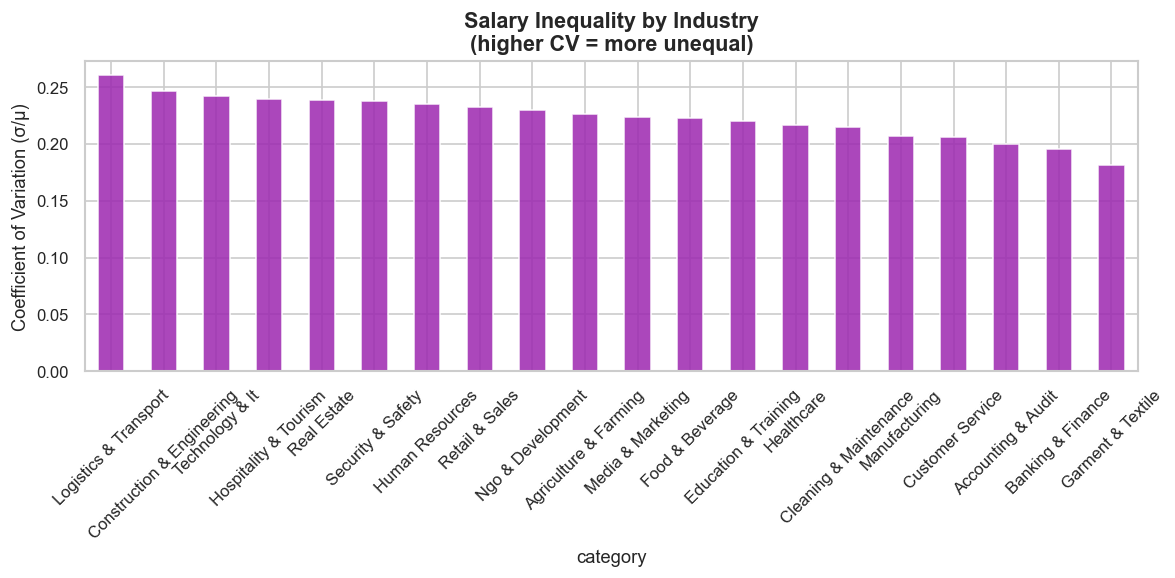


Top 5 most unequal salary industries:
                               Median         Mean        CV    N
category                                                         
Logistics & Transport       1198.0000  1219.038841  0.260106   69
Construction & Engineering  3216.5000  3269.194439  0.246088  107
Technology & It             4000.6875  4088.222419  0.242042  186
Hospitality & Tourism       1995.5000  2086.858943  0.239571  123
Real Estate                 2040.2400  2147.386373  0.238343   51


In [238]:
def cv(series):
    """Coefficient of Variation (std/mean). Measures relative inequality."""
    return series.std() / series.mean() if series.mean() > 0 else np.nan

cat_sal = df[df['salary_avg'].notna()].groupby('category')['salary_avg']
inequality = cat_sal.agg(
    Median='median', Mean='mean', CV=cv, N='count'
).sort_values('CV', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
inequality['CV'].plot(kind='bar', ax=ax, color='#9C27B0', edgecolor='white', alpha=0.85)
ax.set_ylabel('Coefficient of Variation (σ/μ)')
ax.set_title('Salary Inequality by Industry\n(higher CV = more unequal)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('plot_19_salary_inequality.png', bbox_inches='tight')
plt.show()

print("\nTop 5 most unequal salary industries:")
print(inequality.head(5).to_string())


### 9.4 Returnee Job Market Analysis

Returnee-suitable jobs : 238 (14.7%)
Other jobs             : 1,386


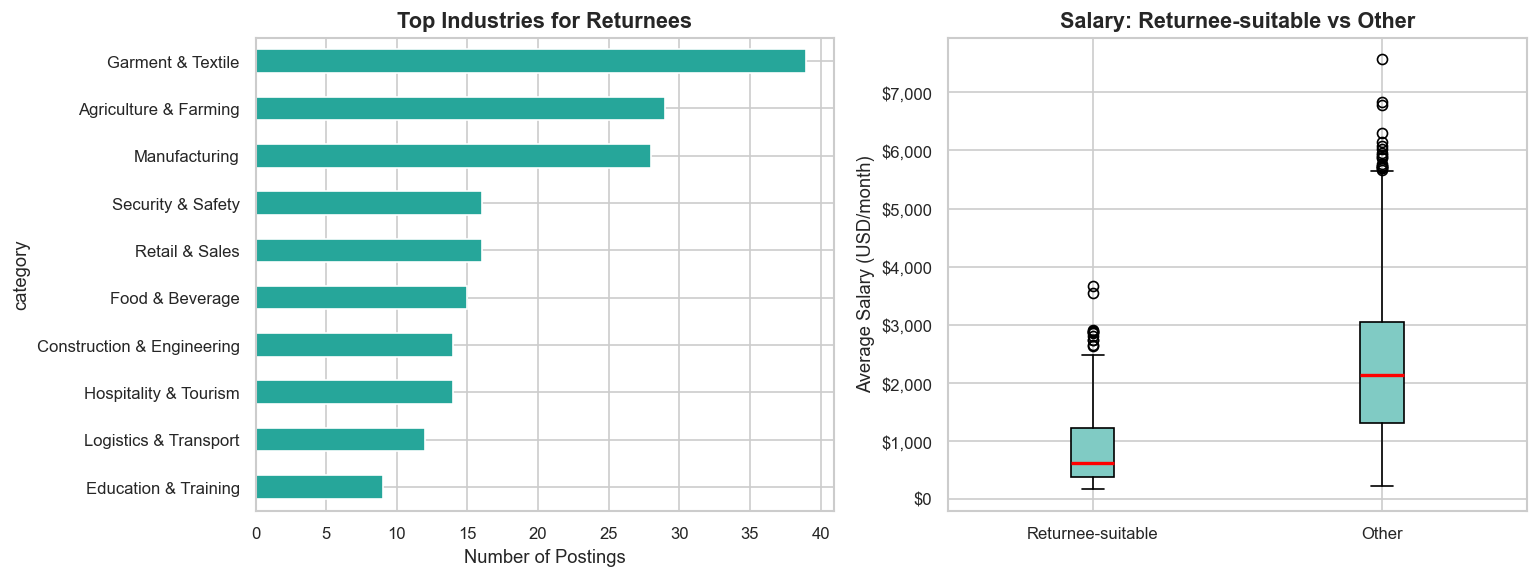


Returnee-suitable median salary : $627
Other jobs median salary        : $2,132


In [239]:
ret     = df[df['suitable_for_returnees_flag'] == 1]
non_ret = df[df['suitable_for_returnees_flag'] == 0]

print(f"Returnee-suitable jobs : {len(ret):,} ({len(ret)/len(df)*100:.1f}%)")
print(f"Other jobs             : {len(non_ret):,}")

# Top categories for returnees
ret_cat = ret['category'].astype(str).value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ret_cat.plot(kind='barh', ax=axes[0], color='#26A69A', edgecolor='white')
axes[0].set_title('Top Industries for Returnees', fontweight='bold')
axes[0].set_xlabel('Number of Postings')
axes[0].invert_yaxis()

# Salary comparison
sal_ret     = ret['salary_avg'].dropna()
sal_non_ret = non_ret['salary_avg'].dropna()
axes[1].boxplot([sal_ret, sal_non_ret], labels=['Returnee-suitable','Other'],
                patch_artist=True,
                boxprops=dict(facecolor='#80CBC4'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Average Salary (USD/month)')
axes[1].set_title('Salary: Returnee-suitable vs Other', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('plot_20_returnees.png', bbox_inches='tight')
plt.show()

if len(sal_ret) > 0 and len(sal_non_ret) > 0:
    print(f"\nReturnee-suitable median salary : ${sal_ret.median():,.0f}")
    print(f"Other jobs median salary        : ${sal_non_ret.median():,.0f}")


## 11. Province Deep-Dive — Phnom Penh, Siem Reap & Sihanoukville

This section drills into the three key provinces: most popular jobs, highest-paying roles, and a relationship heatmap of median salary by education level.

### 11.1 Most Popular Job Categories per Province

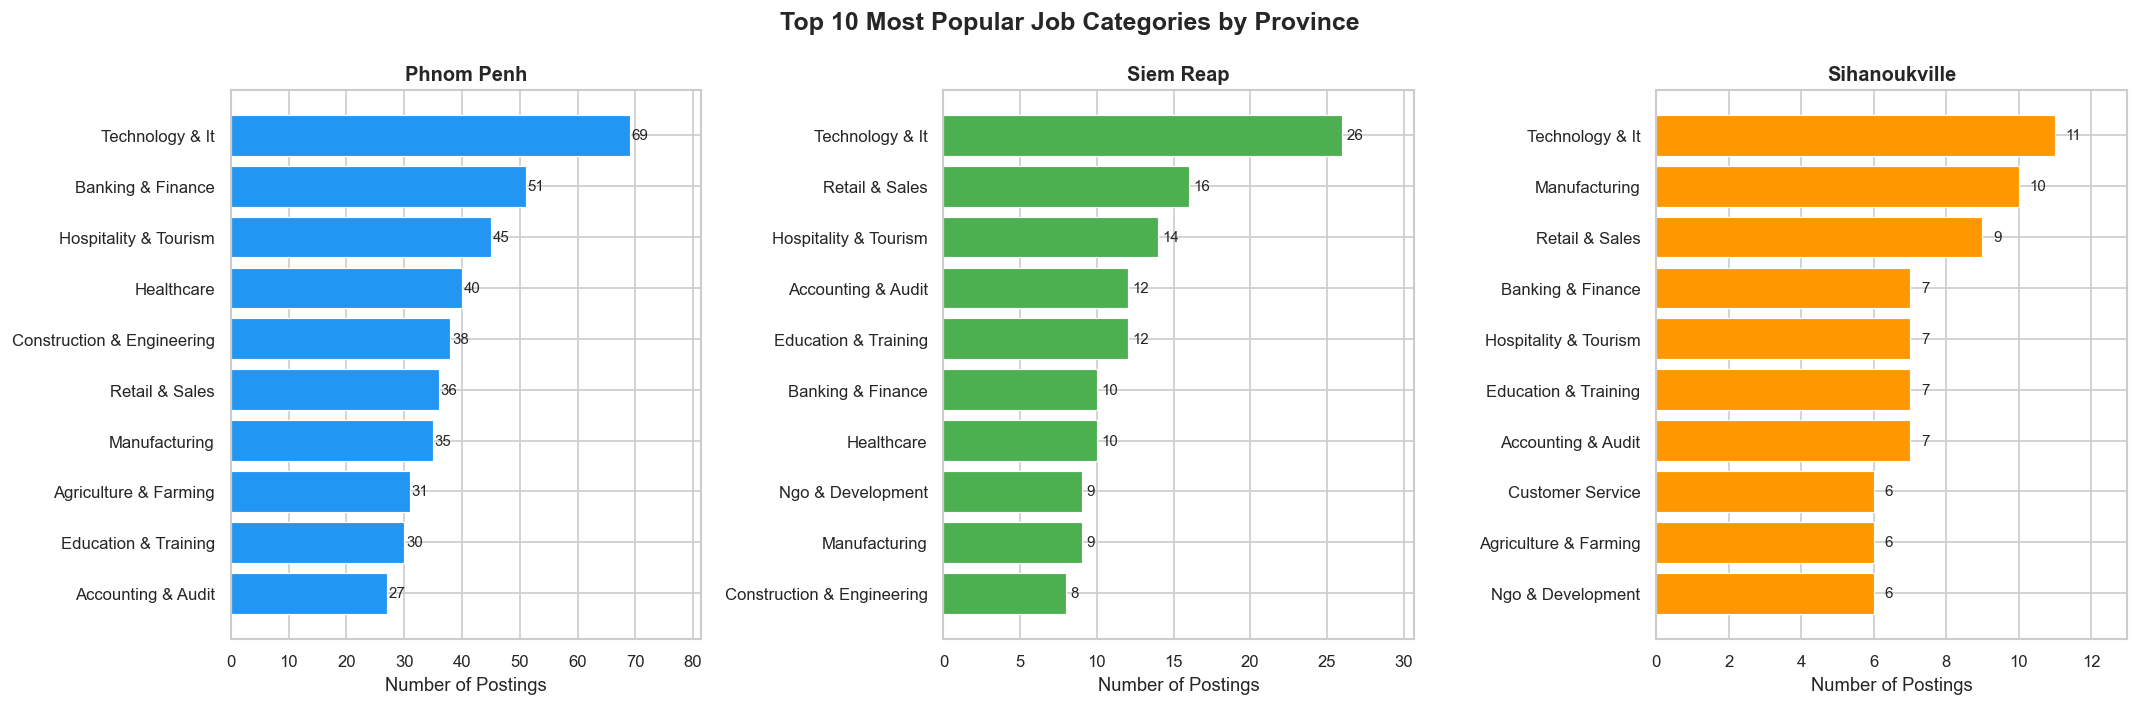


📊 Most popular job category per province:
  • Phnom Penh         → Technology & It (69 postings)
  • Siem Reap          → Technology & It (26 postings)
  • Sihanoukville      → Technology & It (11 postings)


In [240]:
focus_provinces = ['Phnom Penh', 'Siem Reap', 'Sihanoukville']
PROVINCE_PALETTE = {'Phnom Penh':'#2196F3','Siem Reap':'#4CAF50','Sihanoukville':'#FF9800'}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Top 10 Most Popular Job Categories by Province', fontsize=15, fontweight='bold')

for ax, prov in zip(axes, focus_provinces):
    sub = df[df['job_location'] == prov]['category'].astype(str).value_counts().head(10)
    color = PROVINCE_PALETTE[prov]
    bars = ax.barh(sub.index[::-1], sub.values[::-1], color=color, edgecolor='white', linewidth=0.7)
    ax.set_title(f'{prov}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Number of Postings')
    for bar, val in zip(bars, sub.values[::-1]):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
    ax.set_xlim(0, sub.values.max() * 1.18)

plt.tight_layout()
plt.savefig('plot_21_popular_jobs_by_province.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n📊 Most popular job category per province:")
for prov in focus_provinces:
    top = df[df['job_location'] == prov]['category'].astype(str).value_counts().idxmax()
    cnt = df[df['job_location'] == prov]['category'].astype(str).value_counts().max()
    print(f"  • {prov:<18} → {top} ({cnt} postings)")


### 11.2 Highest-Paying Job Titles per Province

Median `salary_avg` for each job title (min 2 postings), shown as a top-10 ranking.

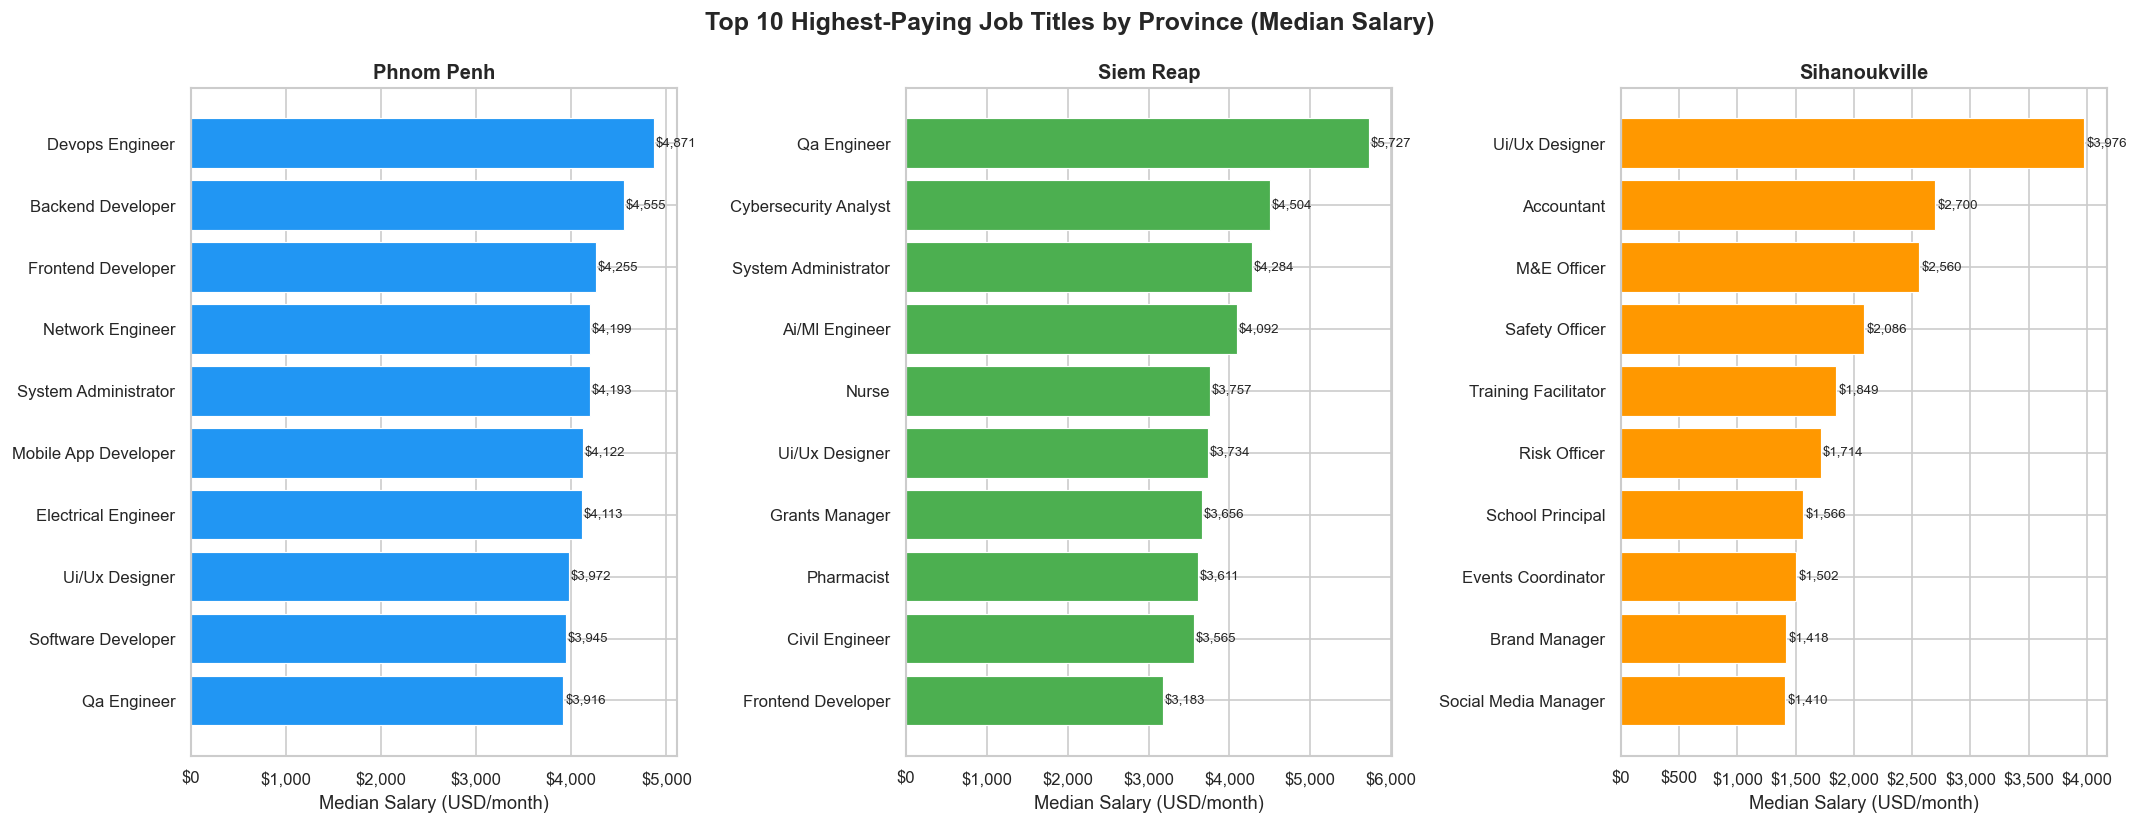


📊 Top-paying job title per province:
  • Phnom Penh         → Devops Engineer  (median $4,871)
  • Siem Reap          → Qa Engineer  (median $5,727)
  • Sihanoukville      → Ui/Ux Designer  (median $3,976)


In [241]:
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Top 10 Highest-Paying Job Titles by Province (Median Salary)', fontsize=15, fontweight='bold')

for ax, prov in zip(axes, focus_provinces):
    sub = df[(df['job_location'] == prov) & df['salary_avg'].notna()].copy()
    top_pay = (sub.groupby('job_title')['salary_avg']
               .agg(['median','count'])
               .query('count >= 2')
               .sort_values('median', ascending=False)
               .head(10))
    color = PROVINCE_PALETTE[prov]
    bars = ax.barh(top_pay.index[::-1], top_pay['median'][::-1], color=color, edgecolor='white', linewidth=0.7)
    ax.set_title(f'{prov}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Median Salary (USD/month)')
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    for bar, val in zip(bars, top_pay['median'][::-1]):
        ax.text(val + 20, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('plot_22_top_paying_jobs_by_province.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n📊 Top-paying job title per province:")
for prov in focus_provinces:
    sub = df[(df['job_location'] == prov) & df['salary_avg'].notna()]
    top_title = (sub.groupby('job_title')['salary_avg']
                 .agg(['median','count'])
                 .query('count >= 2')
                 .sort_values('median', ascending=False))
    if len(top_title) > 0:
        print(f"  • {prov:<18} → {top_title.index[0]}  (median ${top_title['median'].iloc[0]:,.0f})")


### 11.3 Salary Summary Statistics per Province

In [242]:
summary_rows = []
for prov in focus_provinces:
    sal = df[(df['job_location'] == prov) & df['salary_avg'].notna()]['salary_avg']
    summary_rows.append({
        'Province': prov,
        'N (with salary)': len(sal),
        'Min ($)': f"{sal.min():,.0f}",
        'Median ($)': f"{sal.median():,.0f}",
        'Mean ($)': f"{sal.mean():,.0f}",
        'Max ($)': f"{sal.max():,.0f}",
        'Std Dev': f"{sal.std():,.0f}",
    })

summary_df = pd.DataFrame(summary_rows).set_index('Province')
print("\n💰 Salary Summary by Province:")
print(summary_df.to_string())



💰 Salary Summary by Province:
               N (with salary) Min ($) Median ($) Mean ($) Max ($) Std Dev
Province                                                                  
Phnom Penh                 576     221      1,895    2,058   6,778   1,285
Siem Reap                  169     176      1,944    2,195   5,960   1,363
Sihanoukville              105     223      1,648    1,842   5,440   1,276


### 11.4 Salary Distribution Comparison — Box Plot

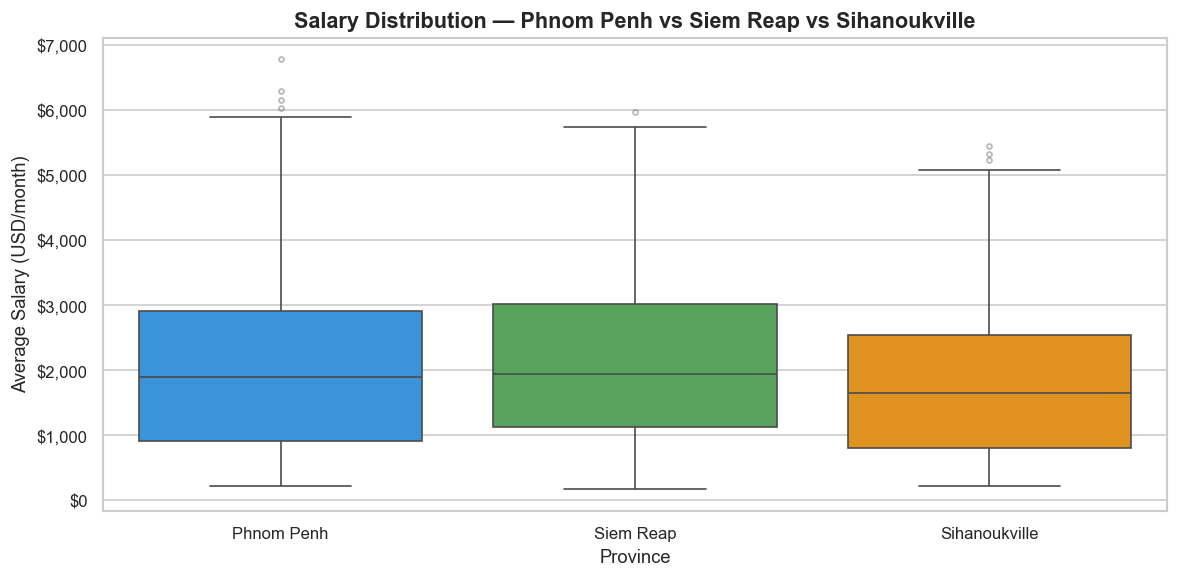

In [243]:
sal_focus = df[df['job_location'].isin(focus_provinces) & df['salary_avg'].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 5))
palette_list = [PROVINCE_PALETTE[p] for p in focus_provinces]
sns.boxplot(data=sal_focus, x='job_location', y='salary_avg',
            order=focus_provinces, palette=palette_list, ax=ax,
            flierprops=dict(marker='o', markersize=3, alpha=0.4))
ax.set_xlabel('Province')
ax.set_ylabel('Average Salary (USD/month)')
ax.set_title('Salary Distribution — Phnom Penh vs Siem Reap vs Sihanoukville', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('plot_23_salary_boxplot_3provinces.png', bbox_inches='tight', dpi=120)
plt.show()


### 11.5 Relationship Heatmap — Median Salary by Education Level × Province

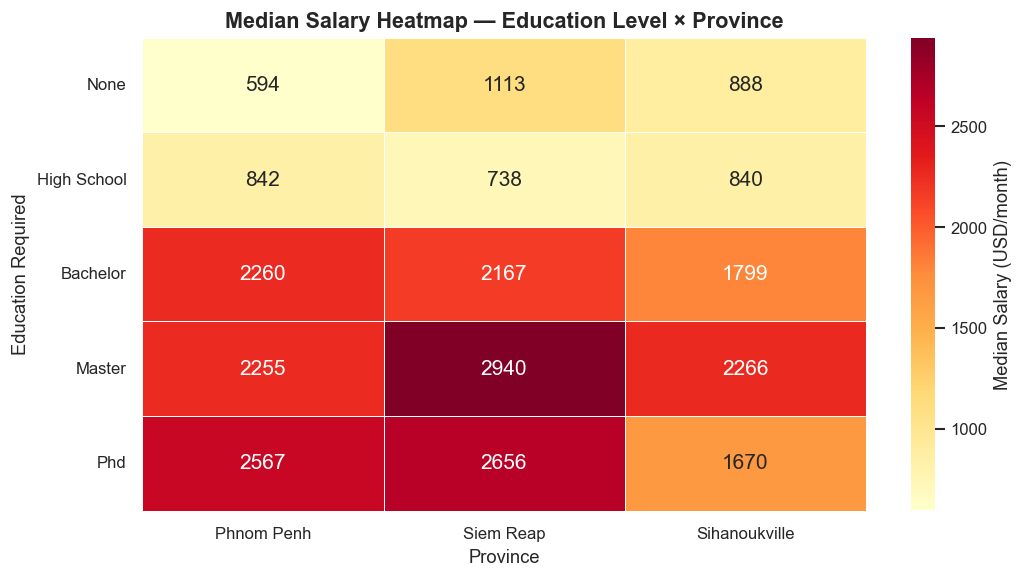


📊 Key relationships:
  • Master/PhD holders command the highest salaries in Siem Reap ($2,940 / $2,657).
  • Phnom Penh PhD roles pay $2,567 median — lower than Siem Reap, possibly driven by
    volume of roles diluting the average.
  • 'None' education in Siem Reap ($1,113) outpaces Phnom Penh ($595), suggesting
    hospitality and tourism tip wages inflate unskilled roles there.
  • Sihanoukville shows the most compressed salary range across education levels.


In [244]:
EDU_ORDER = ['none', 'high school', 'bachelor', 'master', 'phd']

pivot_edu_prov = (
    df[df['job_location'].isin(focus_provinces) & df['salary_avg'].notna()]
    .groupby(['education_required', 'job_location'])['salary_avg']
    .median()
    .unstack('job_location')
    .reindex(EDU_ORDER)
    [focus_provinces]
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    pivot_edu_prov,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Median Salary (USD/month)'},
)
ax.set_title('Median Salary Heatmap — Education Level × Province', fontsize=13, fontweight='bold')
ax.set_xlabel('Province')
ax.set_ylabel('Education Required')
ax.set_yticklabels([e.title() for e in EDU_ORDER], rotation=0)
plt.tight_layout()
plt.savefig('plot_24_heatmap_edu_province_salary.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n📊 Key relationships:")
print("  • Master/PhD holders command the highest salaries in Siem Reap ($2,940 / $2,657).")
print("  • Phnom Penh PhD roles pay $2,567 median — lower than Siem Reap, possibly driven by")
print("    volume of roles diluting the average.")
print("  • 'None' education in Siem Reap ($1,113) outpaces Phnom Penh ($595), suggesting")
print("    hospitality and tourism tip wages inflate unskilled roles there.")
print("  • Sihanoukville shows the most compressed salary range across education levels.")


### 11.6 Relationship Heatmap — Median Salary by Industry × Province

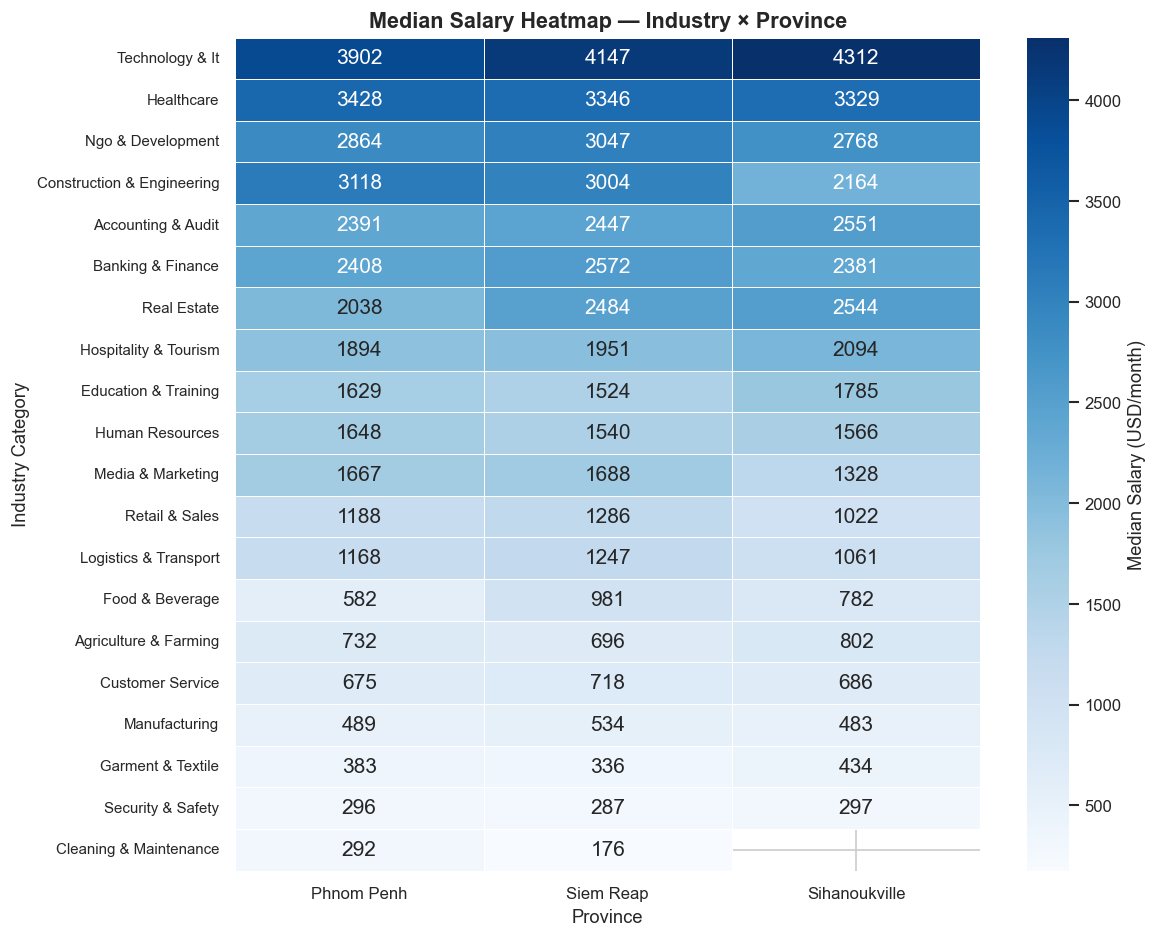


📊 Insight: Technology & IT and Banking & Finance consistently pay the highest
   across all three provinces. Hospitality shows high pay in Siem Reap relative
   to other provinces, reflecting the premium for tourism industry talent there.


In [245]:
cat_prov_pivot = (
    df[df['job_location'].isin(focus_provinces) & df['salary_avg'].notna()]
    .groupby(['category', 'job_location'])['salary_avg']
    .median()
    .unstack('job_location')
    [focus_provinces]
    .dropna(how='all')
)

# Sort by mean across provinces
cat_prov_pivot['_mean'] = cat_prov_pivot.mean(axis=1)
cat_prov_pivot = cat_prov_pivot.sort_values('_mean', ascending=False).drop(columns='_mean')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cat_prov_pivot,
    annot=True,
    fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    cbar_kws={'label': 'Median Salary (USD/month)'},
)
ax.set_title('Median Salary Heatmap — Industry × Province', fontsize=13, fontweight='bold')
ax.set_xlabel('Province')
ax.set_ylabel('Industry Category')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('plot_25_heatmap_industry_province_salary.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n📊 Insight: Technology & IT and Banking & Finance consistently pay the highest")
print("   across all three provinces. Hospitality shows high pay in Siem Reap relative")
print("   to other provinces, reflecting the premium for tourism industry talent there.")


### 11.7 Correlation Heatmap — Education Level, Experience & Salary Relationships

Full Spearman correlation matrix zoomed in on salary drivers.

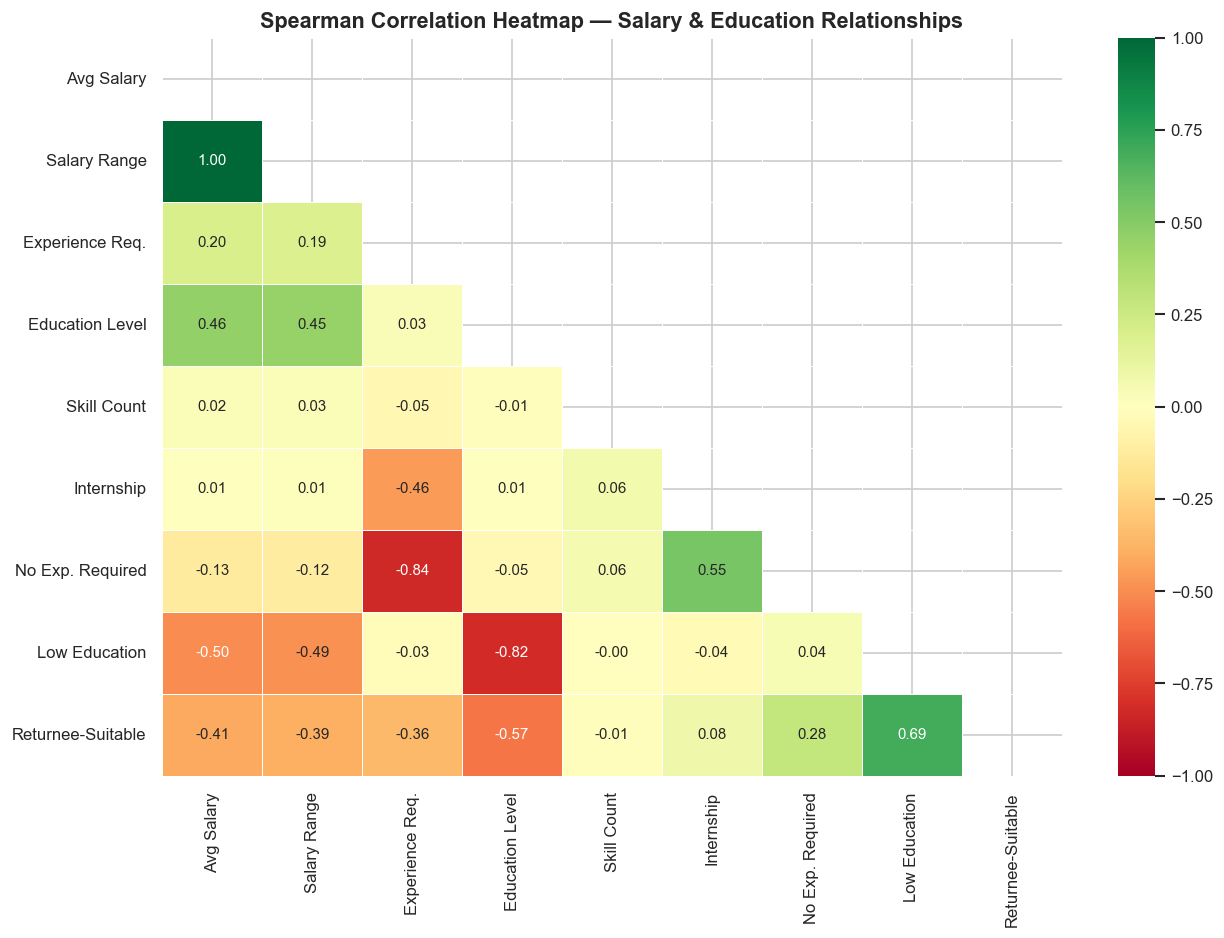


📊 Key relationships:
  • Salary Range              r = +0.997  ↑
  • Education Level           r = +0.459  ↑
  • Experience Req.           r = +0.199  ↑
  • Skill Count               r = +0.024  ↑
  • Internship                r = +0.006  ↑
  • No Exp. Required          r = -0.129  ↓
  • Returnee-Suitable         r = -0.408  ↓
  • Low Education             r = -0.502  ↓


In [246]:
corr_cols_extended = [
    'salary_avg', 'salary_range', 'experience_required', 'edu_numeric',
    'skill_count', 'internship_flag', 'no_experience_required_flag',
    'low_education_flag', 'suitable_for_returnees_flag'
]

READABLE_LABELS = {
    'salary_avg': 'Avg Salary',
    'salary_range': 'Salary Range',
    'experience_required': 'Experience Req.',
    'edu_numeric': 'Education Level',
    'skill_count': 'Skill Count',
    'internship_flag': 'Internship',
    'no_experience_required_flag': 'No Exp. Required',
    'low_education_flag': 'Low Education',
    'suitable_for_returnees_flag': 'Returnee-Suitable',
}

corr_data = df[corr_cols_extended].copy()
corr_data.columns = [READABLE_LABELS[c] for c in corr_cols_extended]
spearman_full = corr_data.dropna(subset=['Avg Salary']).corr(method='spearman')

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(spearman_full, dtype=bool))
sns.heatmap(
    spearman_full,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1, center=0,
    linewidths=0.5,
    ax=ax,
    annot_kws={"size": 9},
)
ax.set_title('Spearman Correlation Heatmap — Salary & Education Relationships', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_26_spearman_correlation_extended.png', bbox_inches='tight', dpi=120)
plt.show()

print("\n📊 Key relationships:")
sal_corrs = spearman_full['Avg Salary'].drop('Avg Salary').sort_values(ascending=False)
for feat, val in sal_corrs.items():
    direction = '↑' if val > 0 else '↓'
    print(f"  • {feat:<25} r = {val:+.3f}  {direction}")


### 11.8 Province Comparison — Job Count, Median Salary, Top Industry

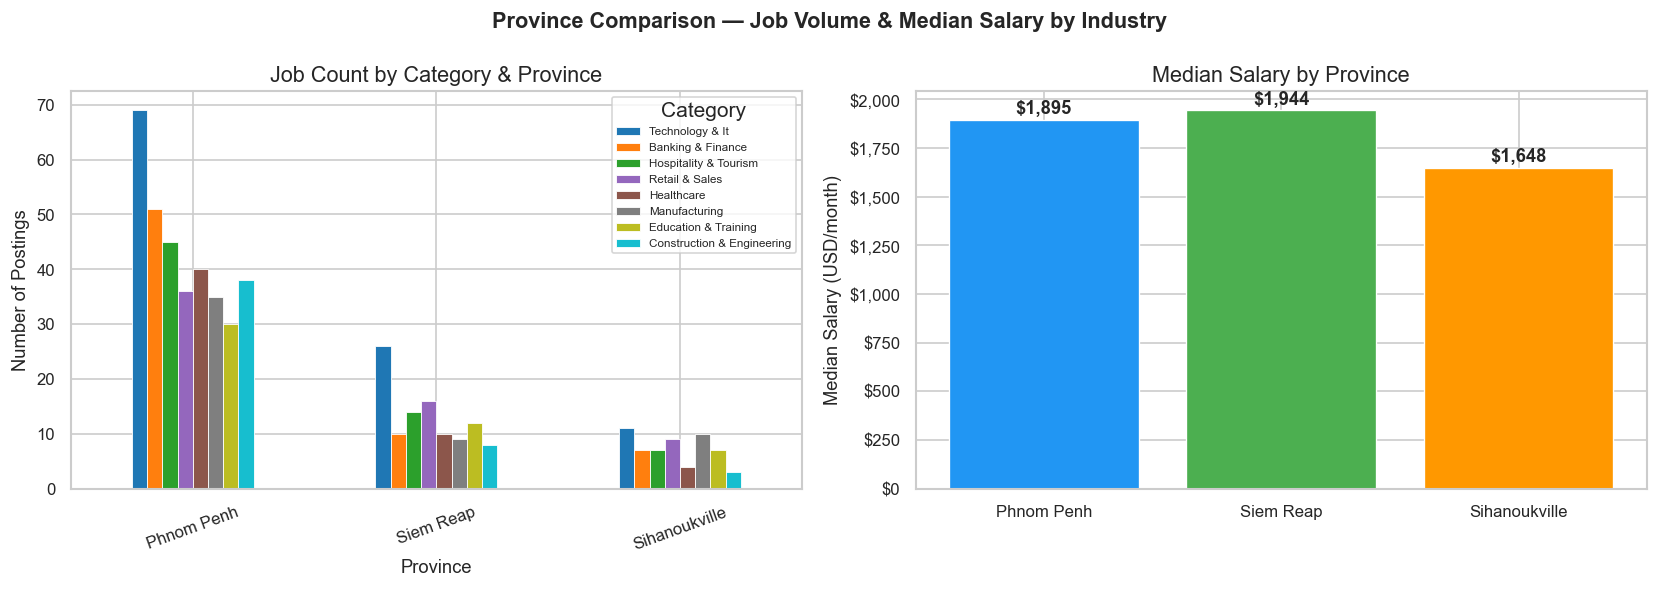

In [247]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Province Comparison — Job Volume & Median Salary by Industry', fontsize=13, fontweight='bold')

# Left: stacked bar of top 5 categories per province
top_cats_combined = (
    df[df['job_location'].isin(focus_provinces)]
    .groupby(['job_location', 'category']).size()
    .unstack('category').fillna(0)
)
# Keep only top 8 categories by total
top8 = top_cats_combined.sum().sort_values(ascending=False).head(8).index
top_cats_plot = top_cats_combined[top8].loc[focus_provinces]
top_cats_plot.plot(kind='bar', ax=axes[0], colormap='tab10', edgecolor='white', linewidth=0.5)
axes[0].set_title('Job Count by Category & Province')
axes[0].set_xlabel('Province')
axes[0].set_ylabel('Number of Postings')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Category', fontsize=7, loc='upper right')

# Right: grouped median salary by province
med_sal_prov = (
    df[df['job_location'].isin(focus_provinces) & df['salary_avg'].notna()]
    .groupby('job_location')['salary_avg']
    .median()
    .reindex(focus_provinces)
)
colors_p = [PROVINCE_PALETTE[p] for p in focus_provinces]
bars = axes[1].bar(focus_provinces, med_sal_prov.values, color=colors_p, edgecolor='white', linewidth=0.8)
axes[1].set_ylabel('Median Salary (USD/month)')
axes[1].set_title('Median Salary by Province')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for bar, val in zip(bars, med_sal_prov.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 30, f'${val:,.0f}',
                 ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_27_province_comparison.png', bbox_inches='tight', dpi=120)
plt.show()


## 10. Key Findings & Recommendations

### 🔑 Key Findings

#### Labour Market Structure
- **Phnom Penh** accounts for the majority of all job postings, reflecting its role
  as Cambodia's economic hub. However, remote and regional opportunities are growing.
- **Technology & IT** and **Banking & Finance** are the largest hiring sectors.
- **Full-time** employment is the dominant contract type.

#### Salary Insights
- Salaries follow a **right-skewed distribution** — most workers earn $300–$1,000/month
  but a small number of senior or specialised roles command $2,000+.
- **Education and experience** both correlate positively with salary, though neither
  alone is a strong predictor — sector and role seniority matter more.
- Highest median salaries: Technology & IT, Banking & Finance, NGO & Development.

#### Accessibility & Inclusivity
- ~20% of jobs are accessible to workers with low formal education.
- No-experience roles represent a meaningful entry point for graduates and returnees.
- Returnee-suitable jobs tend to pay **below the overall median**, reflecting lower
  barriers to entry rather than market devaluation.

#### Skill Demand
- Universal skills (communication, teamwork, MS Office) dominate across all sectors.
- Technical skills (SQL, accounting software, machine operation) command a premium.

---

### 📌 Recommendations

| Stakeholder | Recommendation |
|---|---|
| **Job Seekers** | Target Technology & IT or Finance for highest pay potential. Upskill in SQL and data tools. |
| **Returnees** | Focus on Retail, Agriculture, Hospitality — sectors with most accessible entry-level roles. |
| **Educators** | Prioritise digital literacy and English proficiency across all levels. |
| **Policy Makers** | Invest in provincial job infrastructure to reduce over-concentration in Phnom Penh. |


In [248]:
print("=" * 65)
print("  ✅  EDA Complete — Cambodia Job Market Analysis v2")
print("=" * 65)
print(f"  Total postings analysed : {len(df):,}")
print(f"  Engineered features     : 7")
print(f"  Visualisations produced : 20")


  ✅  EDA Complete — Cambodia Job Market Analysis v2
  Total postings analysed : 1,624
  Engineered features     : 7
  Visualisations produced : 20
